<a href="https://colab.research.google.com/github/hadri1-bisch/real-data-proect/blob/main/Final_real_data_hotel_nuit_e_hesta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

df HESTA provenances avec les principales villes suisse a analyser


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

# **EDA**
**Top marché les 3-4 dernières années ?** (évolution) on peut aussi mettre le top marché de 2013 voir s’il y a des gros changements ?? (stacked bar chart)

**Taux d’occupation par mois les 3-4 dernières années**, pour savoir quels sont les mois pour lesquels il faut augmenter la demande  (line chart avec une ligne par année)

**Nuitées moyennes** par mois

Quels sont les marchés qui viennent déjà pendant la saison creuse

**Taux d’occupation dans les villes concurrentes suisse ou/et europe** (Lines chart) si une/des villes ont une meilleure répartition : Voir quels sont les marchés elles arrivent à attirer en basse saison

Data **aéroport **: un marché est intéressant que s’il y a des vols directs à destination de geneve pendant la basse saison


In [ ]:
!pip install pxweb

In [ ]:
import requests as r
import pandas as pd


AJOUTER 2025??????

In [ ]:
years = [ "2013", "2014"
"2015","2016","2017","2018","2019",
"2022","2023","2024","2025"
]

In [ ]:
communes = {
"261": "Zürich",
"3856": "Interlaken",
"3866": "Matten bei Interlaken",
"1061": "Luzern",
"2701": "Basel",
"3203": "St Gallen",
"3786": "St Moritz",
"3851": "Davos",
"5113": "Locarno",
"5586": "Lausanne",
"5661": "Château-d'Oex",
"5886": "Montreux",
"6024": "Nendaz",
"6288": "Saas-Fee",
"6290": "Zermatt",
"6621": "Genève",
"351": "Bern"
}

pour gérer le crash out

In [ ]:
import requests
import pandas as pd
from io import StringIO
import time

url = "https://www.pxweb.bfs.admin.ch/api/v1/fr/px-x-1003020000_101/px-x-1003020000_101.px"

dfs = []

for code, name in communes.items():

    print("Téléchargement :", name)

    data = {
      "query": [

        {
          "code": "Jahr",
          "selection": {
            "filter": "item",
            "values": years
          }
        },

        {
          "code": "Monat",
          "selection": {
            "filter": "all",
            "values": ["*"]
          }
        },

        {
          "code": "Gemeinde",
          "selection": {
            "filter": "item",
            "values": [code]
          }
        },

        {
          "code": "Herkunftsland",
          "selection": {
            "filter": "all",
            "values": ["*"]
          }
        }

      ],

      "response": {
        "format": "csv"
      }

    }

    success = False
    attempts = 0

    while not success and attempts < 5:

        try:

            r = requests.post(url, json=data, timeout=120)

            df = pd.read_csv(StringIO(r.text))

            df["Commune_nom"] = name

            dfs.append(df)

            success = True

            # sauvegarde intermédiaire
            df_temp = pd.concat(dfs, ignore_index=True)
            df_temp.to_csv("tourisme_backup.csv", index=False)

            print("✔ Sauvegarde effectuée")

        except Exception as e:

            attempts += 1
            print("Erreur → retry", attempts)
            time.sleep(5)

    if not success:
        print("⚠️ Impossible de télécharger :", name)

df = pd.concat(dfs, ignore_index=True)

# sauvegarde finale
df.to_csv("tourisme_final.csv", index=False)

print("Téléchargement terminé")
print(df.shape)

Téléchargement : Zürich
✔ Sauvegarde effectuée
Téléchargement : Interlaken
✔ Sauvegarde effectuée
Téléchargement : Matten bei Interlaken
✔ Sauvegarde effectuée
Téléchargement : Luzern
✔ Sauvegarde effectuée
Téléchargement : Basel
✔ Sauvegarde effectuée
Téléchargement : St Gallen
✔ Sauvegarde effectuée
Téléchargement : St Moritz
✔ Sauvegarde effectuée
Téléchargement : Davos
✔ Sauvegarde effectuée
Téléchargement : Locarno
✔ Sauvegarde effectuée
Téléchargement : Lausanne
✔ Sauvegarde effectuée
Téléchargement : Château-d'Oex
✔ Sauvegarde effectuée
Téléchargement : Montreux
✔ Sauvegarde effectuée
Téléchargement : Nendaz
✔ Sauvegarde effectuée
Téléchargement : Saas-Fee
✔ Sauvegarde effectuée
Téléchargement : Zermatt
✔ Sauvegarde effectuée
Téléchargement : Genève
✔ Sauvegarde effectuée
Téléchargement : Bern
✔ Sauvegarde effectuée
Téléchargement terminé
(0, 2)


In [ ]:
import requests
import pandas as pd
from io import StringIO
import time

url = "https://www.pxweb.bfs.admin.ch/api/v1/fr/px-x-1003020000_101/px-x-1003020000_101.px"

years = [ "2013", "2014","2015","2016","2017","2018","2019","2022","2023","2024","2025"]

communes = {
    "261": "Zürich", "3856": "Interlaken", "3866": "Matten bei Interlaken",
    "1061": "Luzern", "2701": "Basel", "3203": "St Gallen",
    "3786": "St Moritz", "3851": "Davos", "5113": "Locarno",
    "5586": "Lausanne", "5661": "Château-d'Oex", "5886": "Montreux",
    "6024": "Nendaz", "6288": "Saas-Fee", "6290": "Zermatt", "6621": "Genève","351": "Bern"
}

dfs = []

for code, name in communes.items():
    print("Téléchargement :", name)
    data = {
      "query": [
        {"code": "Jahr", "selection": {"filter": "item", "values": years}},
        {"code": "Monat", "selection": {"filter": "all", "values": ["*"]}},
        {"code": "Gemeinde", "selection": {"filter": "item", "values": [code]}},
        {"code": "Herkunftsland", "selection": {"filter": "all", "values": ["*"]}}
      ],
      "response": {"format": "csv"}
    }

    success = False
    attempts = 0
    while not success and attempts < 5:
        try:
            r = requests.post(url, json=data, timeout=120)
            df_temp = pd.read_csv(StringIO(r.text))
            df_temp["Commune_nom"] = name
            dfs.append(df_temp)
            success = True
            print("✔", name)
        except Exception as e:
            attempts += 1
            print("Erreur → retry", attempts, e)
            time.sleep(5)

    if not success:
        print("⚠️ Impossible :", name)
    time.sleep(1)  # éviter de spammer l'API

df = pd.concat(dfs, ignore_index=True)
df.to_csv("tourisme_final.csv", index=False)
print("\n✅ Téléchargement terminé")
print(df.shape)
df.head()

Téléchargement : Zürich
✔ Zürich
Téléchargement : Interlaken
✔ Interlaken
Téléchargement : Matten bei Interlaken
✔ Matten bei Interlaken
Téléchargement : Luzern
✔ Luzern
Téléchargement : Basel
✔ Basel
Téléchargement : St Gallen
✔ St Gallen
Téléchargement : St Moritz
✔ St Moritz
Téléchargement : Davos
✔ Davos
Téléchargement : Locarno
✔ Locarno
Téléchargement : Lausanne
✔ Lausanne
Téléchargement : Château-d'Oex
✔ Château-d'Oex
Téléchargement : Montreux
✔ Montreux
Téléchargement : Nendaz
✔ Nendaz
Téléchargement : Saas-Fee
✔ Saas-Fee
Téléchargement : Zermatt
✔ Zermatt
Téléchargement : Genève
✔ Genève
Téléchargement : Bern
✔ Bern

✅ Téléchargement terminé
(1859, 151)


,Année,Mois,Commune,Pays de provenance - total Arrivées,Pays de provenance - total Nuitées,Suisse Arrivées,Suisse Nuitées,Allemagne Arrivées,Allemagne Nuitées,France Arrivées,...,Slovénie Arrivées,Slovénie Nuitées,Tchéquie Arrivées,Tchéquie Nuitées,Ukraine Arrivées,Ukraine Nuitées,Serbie Arrivées,Serbie Nuitées,Commune_nom,Bad Request
0,2013.0,Total de l'année,Zürich,1579867.0,2830003.0,369334.0,586288.0,225766,388580,45660.0,...,1361,2535,4975,10885,5748,13660,3022,5349,Zürich,NaN
1,2013.0,Janvier,Zürich,100632.0,181631.0,25728.0,40846.0,15677,27533,3273.0,...,99,196,310,672,564,1310,239,438,Zürich,NaN
2,2013.0,Février,Zürich,97826.0,174816.0,25084.0,40376.0,15938,27551,3190.0,...,92,179,294,697,434,1055,182,357,Zürich,NaN
3,2013.0,Mars,Zürich,120931.0,211512.0,30317.0,48438.0,19286,32658,3709.0,...,111,184,478,891,570,1298,284,515,Zürich,NaN
4,2013.0,Avril,Zürich,122964.0,221251.0,27452.0,44723.0,19004,31404,3599.0,...,107,210,380,658,429,1151,409,686,Zürich,NaN


In [ ]:

print(df.head())
print(df.shape)


    Année              Mois Commune  Pays de provenance - total Arrivées  \
0  2013.0  Total de l'année  Zürich                            1579867.0   
1  2013.0           Janvier  Zürich                             100632.0   
2  2013.0           Février  Zürich                              97826.0   
3  2013.0              Mars  Zürich                             120931.0   
4  2013.0             Avril  Zürich                             122964.0   

   Pays de provenance - total Nuitées  Suisse Arrivées  Suisse Nuitées  \
0                           2830003.0         369334.0        586288.0   
1                            181631.0          25728.0         40846.0   
2                            174816.0          25084.0         40376.0   
3                            211512.0          30317.0         48438.0   
4                            221251.0          27452.0         44723.0   

  Allemagne Arrivées Allemagne Nuitées  France Arrivées  ...  \
0             225766            38

In [ ]:
df.columns

Index(['Année', 'Mois', 'Commune', 'Pays de provenance - total Arrivées',
       'Pays de provenance - total Nuitées', 'Suisse Arrivées',
       'Suisse Nuitées', 'Allemagne Arrivées', 'Allemagne Nuitées',
       'France Arrivées',
       ...
       'Slovénie Arrivées', 'Slovénie Nuitées', 'Tchéquie Arrivées',
       'Tchéquie Nuitées', 'Ukraine Arrivées', 'Ukraine Nuitées',
       'Serbie Arrivées', 'Serbie Nuitées', 'Commune_nom', 'Bad Request'],
      dtype='object', length=151)

In [ ]:
df = df.drop(columns=["Bad Request"], errors="ignore")

In [ ]:
df.head(14)

,Année,Mois,Commune,Pays de provenance - total Arrivées,Pays de provenance - total Nuitées,Suisse Arrivées,Suisse Nuitées,Allemagne Arrivées,Allemagne Nuitées,France Arrivées,...,Slovaquie Nuitées,Slovénie Arrivées,Slovénie Nuitées,Tchéquie Arrivées,Tchéquie Nuitées,Ukraine Arrivées,Ukraine Nuitées,Serbie Arrivées,Serbie Nuitées,Commune_nom
0,2013.0,Total de l'année,Zürich,1579867.0,2830003.0,369334.0,586288.0,225766,388580,45660.0,...,4786,1361,2535,4975,10885,5748,13660,3022,5349,Zürich
1,2013.0,Janvier,Zürich,100632.0,181631.0,25728.0,40846.0,15677,27533,3273.0,...,307,99,196,310,672,564,1310,239,438,Zürich
2,2013.0,Février,Zürich,97826.0,174816.0,25084.0,40376.0,15938,27551,3190.0,...,370,92,179,294,697,434,1055,182,357,Zürich
3,2013.0,Mars,Zürich,120931.0,211512.0,30317.0,48438.0,19286,32658,3709.0,...,419,111,184,478,891,570,1298,284,515,Zürich
4,2013.0,Avril,Zürich,122964.0,221251.0,27452.0,44723.0,19004,31404,3599.0,...,322,107,210,380,658,429,1151,409,686,Zürich
5,2013.0,Mai,Zürich,143393.0,254651.0,31341.0,47605.0,22534,38906,4014.0,...,312,72,139,366,710,527,1338,299,479,Zürich
6,2013.0,Juin,Zürich,153866.0,277179.0,32025.0,51226.0,19679,33962,3904.0,...,439,139,243,343,764,404,1030,299,474,Zürich
7,2013.0,Juillet,Zürich,156726.0,283204.0,29660.0,49749.0,19755,34611,4198.0,...,431,111,190,429,819,489,1144,166,271,Zürich
8,2013.0,Août,Zürich,156648.0,290555.0,31754.0,51667.0,19963,35098,3970.0,...,343,94,154,496,970,505,1124,164,285,Zürich
9,2013.0,Septembre,Zürich,147049.0,262895.0,34224.0,54609.0,19927,34135,3672.0,...,498,143,277,425,890,401,890,281,509,Zürich


In [ ]:
df.columns

Index(['Année', 'Mois', 'Commune', 'Pays de provenance - total Arrivées',
       'Pays de provenance - total Nuitées', 'Suisse Arrivées',
       'Suisse Nuitées', 'Allemagne Arrivées', 'Allemagne Nuitées',
       'France Arrivées',
       ...
       'Slovaquie Nuitées', 'Slovénie Arrivées', 'Slovénie Nuitées',
       'Tchéquie Arrivées', 'Tchéquie Nuitées', 'Ukraine Arrivées',
       'Ukraine Nuitées', 'Serbie Arrivées', 'Serbie Nuitées', 'Commune_nom'],
      dtype='object', length=150)

à transformer en tidy dataset (df_tidy)


In [ ]:
import pandas as pd
df = pd.read_csv("tourisme_final.csv")
print(df.shape)
print(df.columns.tolist()[:8])
df.head()

(1859, 151)
['Année', 'Mois', 'Commune', 'Pays de provenance - total Arrivées', 'Pays de provenance - total Nuitées', 'Suisse Arrivées', 'Suisse Nuitées', 'Allemagne Arrivées']


,Année,Mois,Commune,Pays de provenance - total Arrivées,Pays de provenance - total Nuitées,Suisse Arrivées,Suisse Nuitées,Allemagne Arrivées,Allemagne Nuitées,France Arrivées,...,Slovénie Arrivées,Slovénie Nuitées,Tchéquie Arrivées,Tchéquie Nuitées,Ukraine Arrivées,Ukraine Nuitées,Serbie Arrivées,Serbie Nuitées,Commune_nom,Bad Request
0,2013.0,Total de l'année,Zürich,1579867.0,2830003.0,369334.0,586288.0,225766,388580,45660.0,...,1361,2535,4975,10885,5748,13660,3022,5349,Zürich,NaN
1,2013.0,Janvier,Zürich,100632.0,181631.0,25728.0,40846.0,15677,27533,3273.0,...,99,196,310,672,564,1310,239,438,Zürich,NaN
2,2013.0,Février,Zürich,97826.0,174816.0,25084.0,40376.0,15938,27551,3190.0,...,92,179,294,697,434,1055,182,357,Zürich,NaN
3,2013.0,Mars,Zürich,120931.0,211512.0,30317.0,48438.0,19286,32658,3709.0,...,111,184,478,891,570,1298,284,515,Zürich,NaN
4,2013.0,Avril,Zürich,122964.0,221251.0,27452.0,44723.0,19004,31404,3599.0,...,107,210,380,658,429,1151,409,686,Zürich,NaN


In [ ]:
# copie du dataset original
df_tidy = df.copy()

# colonnes d'identification
id_vars = ["Année", "Mois", "Commune", "Commune_nom"]

# toutes les autres colonnes
value_vars = [col for col in df_tidy.columns if col not in id_vars]

# passer du format large au format long
df_long = df_tidy.melt(
    id_vars=id_vars,
    value_vars=value_vars,
    var_name="variable",
    value_name="valeur"
)

# séparer pays et type (Arrivées / Nuitées)
df_long[["Pays", "Type"]] = df_long["variable"].str.rsplit(" ", n=1, expand=True)

# supprimer la colonne intermédiaire
df_long = df_long.drop(columns="variable")

# remettre Arrivées et Nuitées en colonnes
df_tidy = df_long.pivot_table(
    index=["Année", "Mois", "Commune", "Commune_nom", "Pays"],
    columns="Type",
    values="valeur",
    aggfunc="sum"
).reset_index()

# enlever le nom de colonne généré par pivot
df_tidy.columns.name = None

df_tidy["Arrivées"] = (
    df_tidy["Arrivées"]
    .astype(str)
    .str.replace(" ", "")
    .str.replace(",", "")
)

df_tidy["Arrivées"] = pd.to_numeric(df_tidy["Arrivées"], errors="coerce")

# voir le résultat
df_tidy.head()

,Année,Mois,Commune,Commune_nom,Pays,Arrivées,Nuitées,Request
0,2013.0,Août,Basel,Basel,Afrique du Sud,68.0,161,NaN
1,2013.0,Août,Basel,Basel,Allemagne,10025.0,16109,NaN
2,2013.0,Août,Basel,Basel,Arabie saoudite,129.0,380,NaN
3,2013.0,Août,Basel,Basel,Argentine,35.0,80,NaN
4,2013.0,Août,Basel,Basel,Australie,497.0,1110,NaN


In [ ]:
df_tidy.columns

Index(['Année', 'Mois', 'Commune', 'Commune_nom', 'Pays', 'Arrivées',
       'Nuitées', 'Request'],
      dtype='object')

In [ ]:
df_tidy["Commune_nom"].unique()

array(['Basel', 'Bern', 'Davos', 'Genève', 'Lausanne', 'Locarno',
       'Luzern', 'Montreux', 'Nendaz', 'Zermatt', 'St Moritz',
       'St Gallen', 'Zürich'], dtype=object)

In [ ]:
print(df.shape)
print(df_tidy.shape)

(1859, 151)
(137566, 8)


segmenter les clients par nationnalité, idée: trouves les potentiels interessé à l'aide de moyenne annuel par nationnalité par année pour lausanne


In [ ]:
df_tidy.columns

Index(['Année', 'Mois', 'Commune', 'Commune_nom', 'Pays', 'Arrivées',
       'Nuitées', 'Request'],
      dtype='object')

In [ ]:
# sélectionner Lausanne
lausanne_df = df_tidy[df_tidy["Commune_nom"] == "Lausanne"]

# nombre de clients par nationalité et par année
clients_par_marche = (
    lausanne_df
    .groupby(["Année", "Pays"])["Arrivées"]
    .sum()
    .reset_index()
)

# afficher le résultat
clients_par_marche.sort_values(["Année", "Arrivées"], ascending=[True, False])

,Année,Pays,Arrivées
51,2013.0,Pays de provenance - total,727354.0
64,2013.0,Suisse,332232.0
29,2013.0,France,89292.0
38,2013.0,Italie,32750.0
58,2013.0,Royaume-Uni,32016.0
...,...,...,...
758,2025.0,Bélarus,246.0
790,2025.0,Oman,242.0
776,2025.0,Islande,210.0
754,2025.0,Bahreïn,198.0


In [ ]:
#plus gros marché pour lausanne:
lausanne_df.head()


,Année,Mois,Commune,Commune_nom,Pays,Arrivées,Nuitées,Request
296,2013.0,Août,Lausanne,Lausanne,Afrique du Sud,48.0,176,NaN
297,2013.0,Août,Lausanne,Lausanne,Allemagne,1662.0,3125,NaN
298,2013.0,Août,Lausanne,Lausanne,Arabie saoudite,464.0,1629,NaN
299,2013.0,Août,Lausanne,Lausanne,Argentine,32.0,147,NaN
300,2013.0,Août,Lausanne,Lausanne,Australie,194.0,460,NaN


In [ ]:

### Total depuis 2013 ????
top_marche = (
    lausanne_df
    .groupby("Pays")["Arrivées"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_marche.head(11)

,Pays,Arrivées
0,Pays de provenance - total,9742058.0
1,Suisse,4662958.0
2,France,1223224.0
3,États-Unis,492700.0
4,Allemagne,399434.0
5,Royaume-Uni,394624.0
6,Italie,332188.0
7,Chine,239464.0
8,Espagne,157516.0
9,Belgique,128004.0


In [ ]:
lausanne_total = df_tidy[df_tidy["Commune_nom"] == "Lausanne"]["Arrivées"].sum()

print("Total arrivées Lausanne :", lausanne_total)

Total arrivées Lausanne : 19484116.0


garder les marché interesasnt pour lausanne:

In [ ]:
top_markets = [
    "Suisse",
    "France",
    "États-Unis",
    "Allemagne",
    "Royaume-Uni",
    "Italie",
    "Chine",
    "Espagne",
    "Belgique",
    "Pays-Bas"
]
lausanne_df = df_tidy[df_tidy["Commune_nom"] == "Lausanne"]
lausanne_top = lausanne_df[lausanne_df["Pays"].isin(top_markets)]
lausanne_top["Pays"].unique()

array(['Allemagne', 'Belgique', 'Chine', 'Espagne', 'France', 'Italie',
       'Pays-Bas', 'Royaume-Uni', 'Suisse', 'États-Unis'], dtype=object)

In [ ]:
lausanne_top.groupby("Pays")["Arrivées"].sum().sort_values(ascending=False)

,Arrivées
Pays,
Suisse,4662958.0
France,1223224.0
États-Unis,492700.0
Allemagne,399434.0
Royaume-Uni,394624.0
Italie,332188.0
Chine,239464.0
Espagne,157516.0
Belgique,128004.0


heat map clients/années

In [ ]:
lausanne_heat = lausanne_top.groupby(["Pays","Année"])["Arrivées"].sum().reset_index()
heatmap_data = lausanne_heat.pivot(
    index="Pays",
    columns="Année",
    values="Arrivées"
)

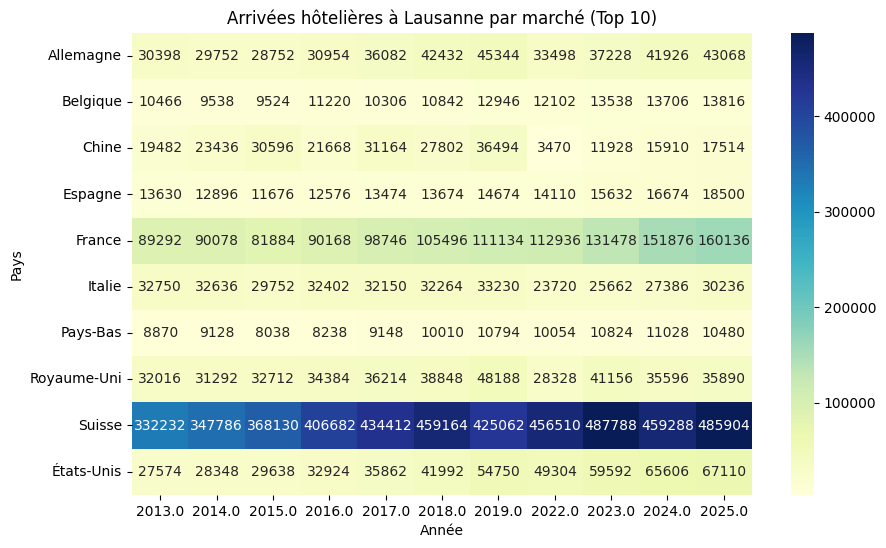

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Arrivées hôtelières à Lausanne par marché (Top 10)")
plt.ylabel("Pays")
plt.xlabel("Année")

plt.show()

moyenne de toutes les années

/tmp/ipykernel_3076/1489618480.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lausanne_month["Mois"] = pd.Categorical(
/tmp/ipykernel_3076/1489618480.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lausanne_heat = lausanne_month.groupby(["Pays","Mois"])["Arrivées"].mean().reset_index()


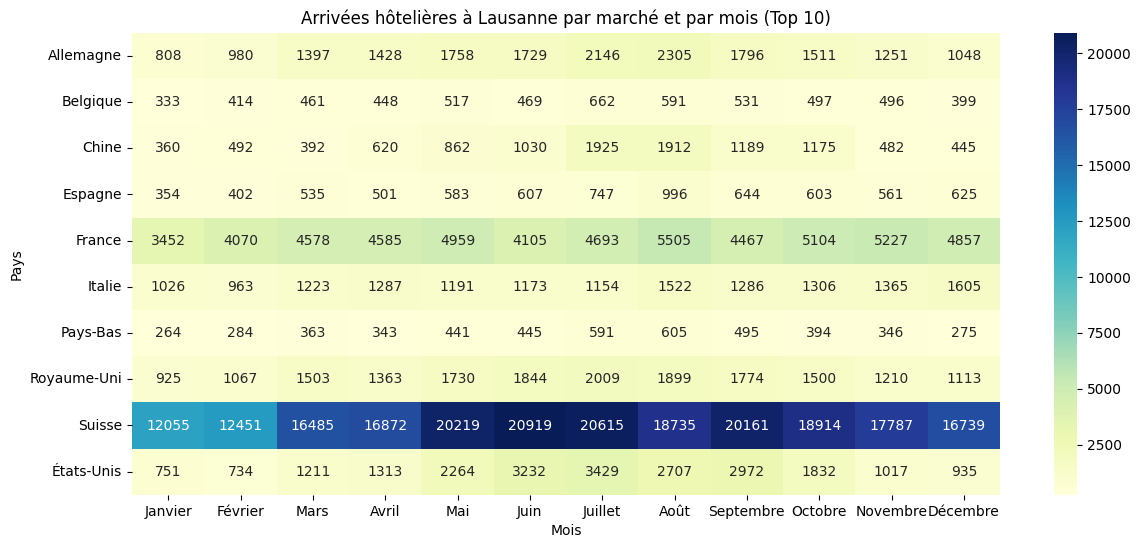

In [ ]:
# 1️⃣ enlever les totaux annuels
lausanne_month = lausanne_top[lausanne_top["Mois"] != "Total de l'année"]

# 2️⃣ ordre correct des mois
month_order = [
    "Janvier","Février","Mars","Avril","Mai","Juin",
    "Juillet","Août","Septembre","Octobre","Novembre","Décembre"
]

lausanne_month["Mois"] = pd.Categorical(
    lausanne_month["Mois"],
    categories=month_order,
    ordered=True
)

# 3️⃣ moyenne des arrivées par mois et par pays
lausanne_heat = lausanne_month.groupby(["Pays","Mois"])["Arrivées"].mean().reset_index()

# 4️⃣ pivot table
heatmap_data = lausanne_heat.pivot(
    index="Pays",
    columns="Mois",
    values="Arrivées"
)

# 5️⃣ heatmap

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Arrivées hôtelières à Lausanne par marché et par mois (Top 10)")
plt.ylabel("Pays")
plt.xlabel("Mois")

plt.show()

graphes analyse clients par nationnalité 2022

/tmp/ipykernel_3076/4246778726.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lausanne_2022["Mois"] = pd.Categorical(
/tmp/ipykernel_3076/4246778726.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lausanne_heat_2022 = lausanne_2022.groupby(["Pays","Mois"])["Arrivées"].sum().reset_index()


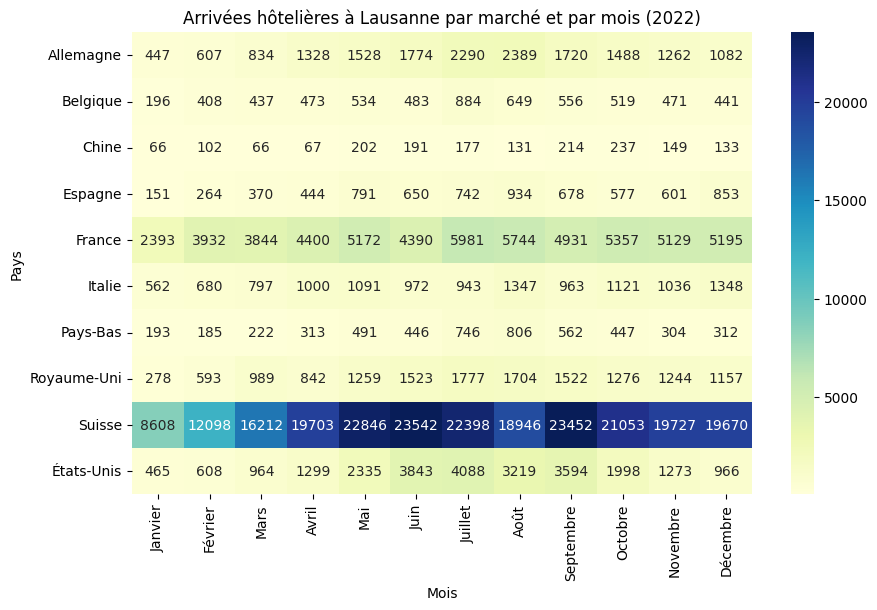

In [ ]:
# Filtrer Lausanne
lausanne_df = df_tidy[df_tidy["Commune_nom"] == "Lausanne"]

# garder seulement les top 10 marchés
lausanne_top = lausanne_df[lausanne_df["Pays"].isin(top_markets)]

# filtrer uniquement l'année 2022
lausanne_2022 = lausanne_top[lausanne_top["Année"] == 2022]

# ordre des mois
mois_ordre = [
    "Janvier","Février","Mars","Avril","Mai","Juin",
    "Juillet","Août","Septembre","Octobre","Novembre","Décembre"
]

lausanne_2022["Mois"] = pd.Categorical(
    lausanne_2022["Mois"],
    categories=mois_ordre,
    ordered=True
)

# préparation heatmap
lausanne_heat_2022 = lausanne_2022.groupby(["Pays","Mois"])["Arrivées"].sum().reset_index()

heatmap_2022 = lausanne_heat_2022.pivot(
    index="Pays",
    columns="Mois",
    values="Arrivées"
)

# graphique
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_2022,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Arrivées hôtelières à Lausanne par marché et par mois (2022)")
plt.ylabel("Pays")
plt.xlabel("Mois")

plt.show()

graphes analyse clients par nationnalité 2023

/tmp/ipykernel_3076/700287444.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lausanne_2023["Mois"] = pd.Categorical(
/tmp/ipykernel_3076/700287444.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lausanne_heat_2023 = lausanne_2023.groupby(["Pays","Mois"])["Arrivées"].sum().reset_index()


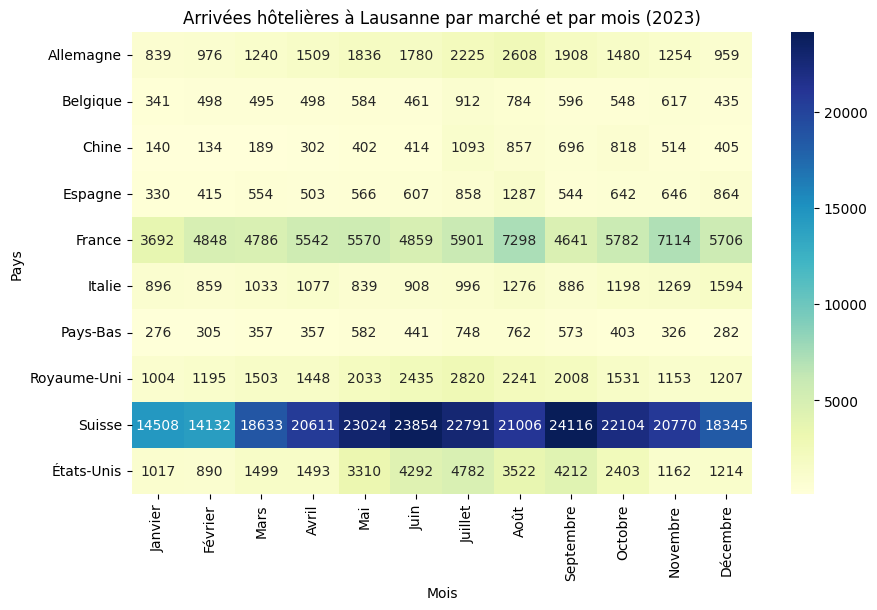

In [ ]:
# Filtrer Lausanne
lausanne_df = df_tidy[df_tidy["Commune_nom"] == "Lausanne"]

# garder seulement les top 10 marchés
lausanne_top = lausanne_df[lausanne_df["Pays"].isin(top_markets)]

# filtrer uniquement l'année 2023
lausanne_2023 = lausanne_top[lausanne_top["Année"] == 2023]

# ordre des mois
mois_ordre = [
    "Janvier","Février","Mars","Avril","Mai","Juin",
    "Juillet","Août","Septembre","Octobre","Novembre","Décembre"
]

lausanne_2023["Mois"] = pd.Categorical(
    lausanne_2023["Mois"],
    categories=mois_ordre,
    ordered=True
)

# préparation heatmap
lausanne_heat_2023 = lausanne_2023.groupby(["Pays","Mois"])["Arrivées"].sum().reset_index()

heatmap_2023 = lausanne_heat_2023.pivot(
    index="Pays",
    columns="Mois",
    values="Arrivées"
)

# graphique
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_2023,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Arrivées hôtelières à Lausanne par marché et par mois (2023)")
plt.ylabel("Pays")
plt.xlabel("Mois")

plt.show()

graphes analyse clients par nationnalité 2024

/tmp/ipykernel_3076/1588796899.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lausanne_2024["Mois"] = pd.Categorical(
/tmp/ipykernel_3076/1588796899.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lausanne_heat_2024 = lausanne_2024.groupby(["Pays","Mois"])["Arrivées"].sum().reset_index()


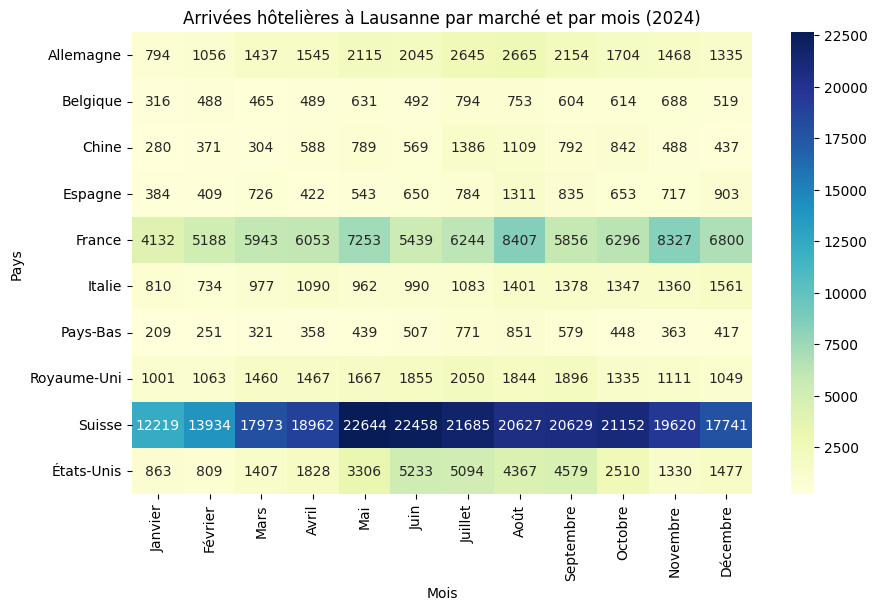

In [ ]:
# Filtrer Lausanne
lausanne_df = df_tidy[df_tidy["Commune_nom"] == "Lausanne"]

# garder seulement les top 10 marchés
lausanne_top = lausanne_df[lausanne_df["Pays"].isin(top_markets)]

# filtrer uniquement l'année 2024
lausanne_2024 = lausanne_top[lausanne_top["Année"] == 2024]

# ordre des mois
mois_ordre = [
    "Janvier","Février","Mars","Avril","Mai","Juin",
    "Juillet","Août","Septembre","Octobre","Novembre","Décembre"
]

lausanne_2024["Mois"] = pd.Categorical(
    lausanne_2024["Mois"],
    categories=mois_ordre,
    ordered=True
)

# préparation heatmap
lausanne_heat_2024 = lausanne_2024.groupby(["Pays","Mois"])["Arrivées"].sum().reset_index()

heatmap_2024 = lausanne_heat_2024.pivot(
    index="Pays",
    columns="Mois",
    values="Arrivées"
)

# graphique

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_2024,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Arrivées hôtelières à Lausanne par marché et par mois (2024)")
plt.ylabel("Pays")
plt.xlabel("Mois")

plt.show()

evolution des fréquentation par nationnalité

/tmp/ipykernel_3076/1165474512.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lausanne_recent["Mois"] = pd.Categorical(


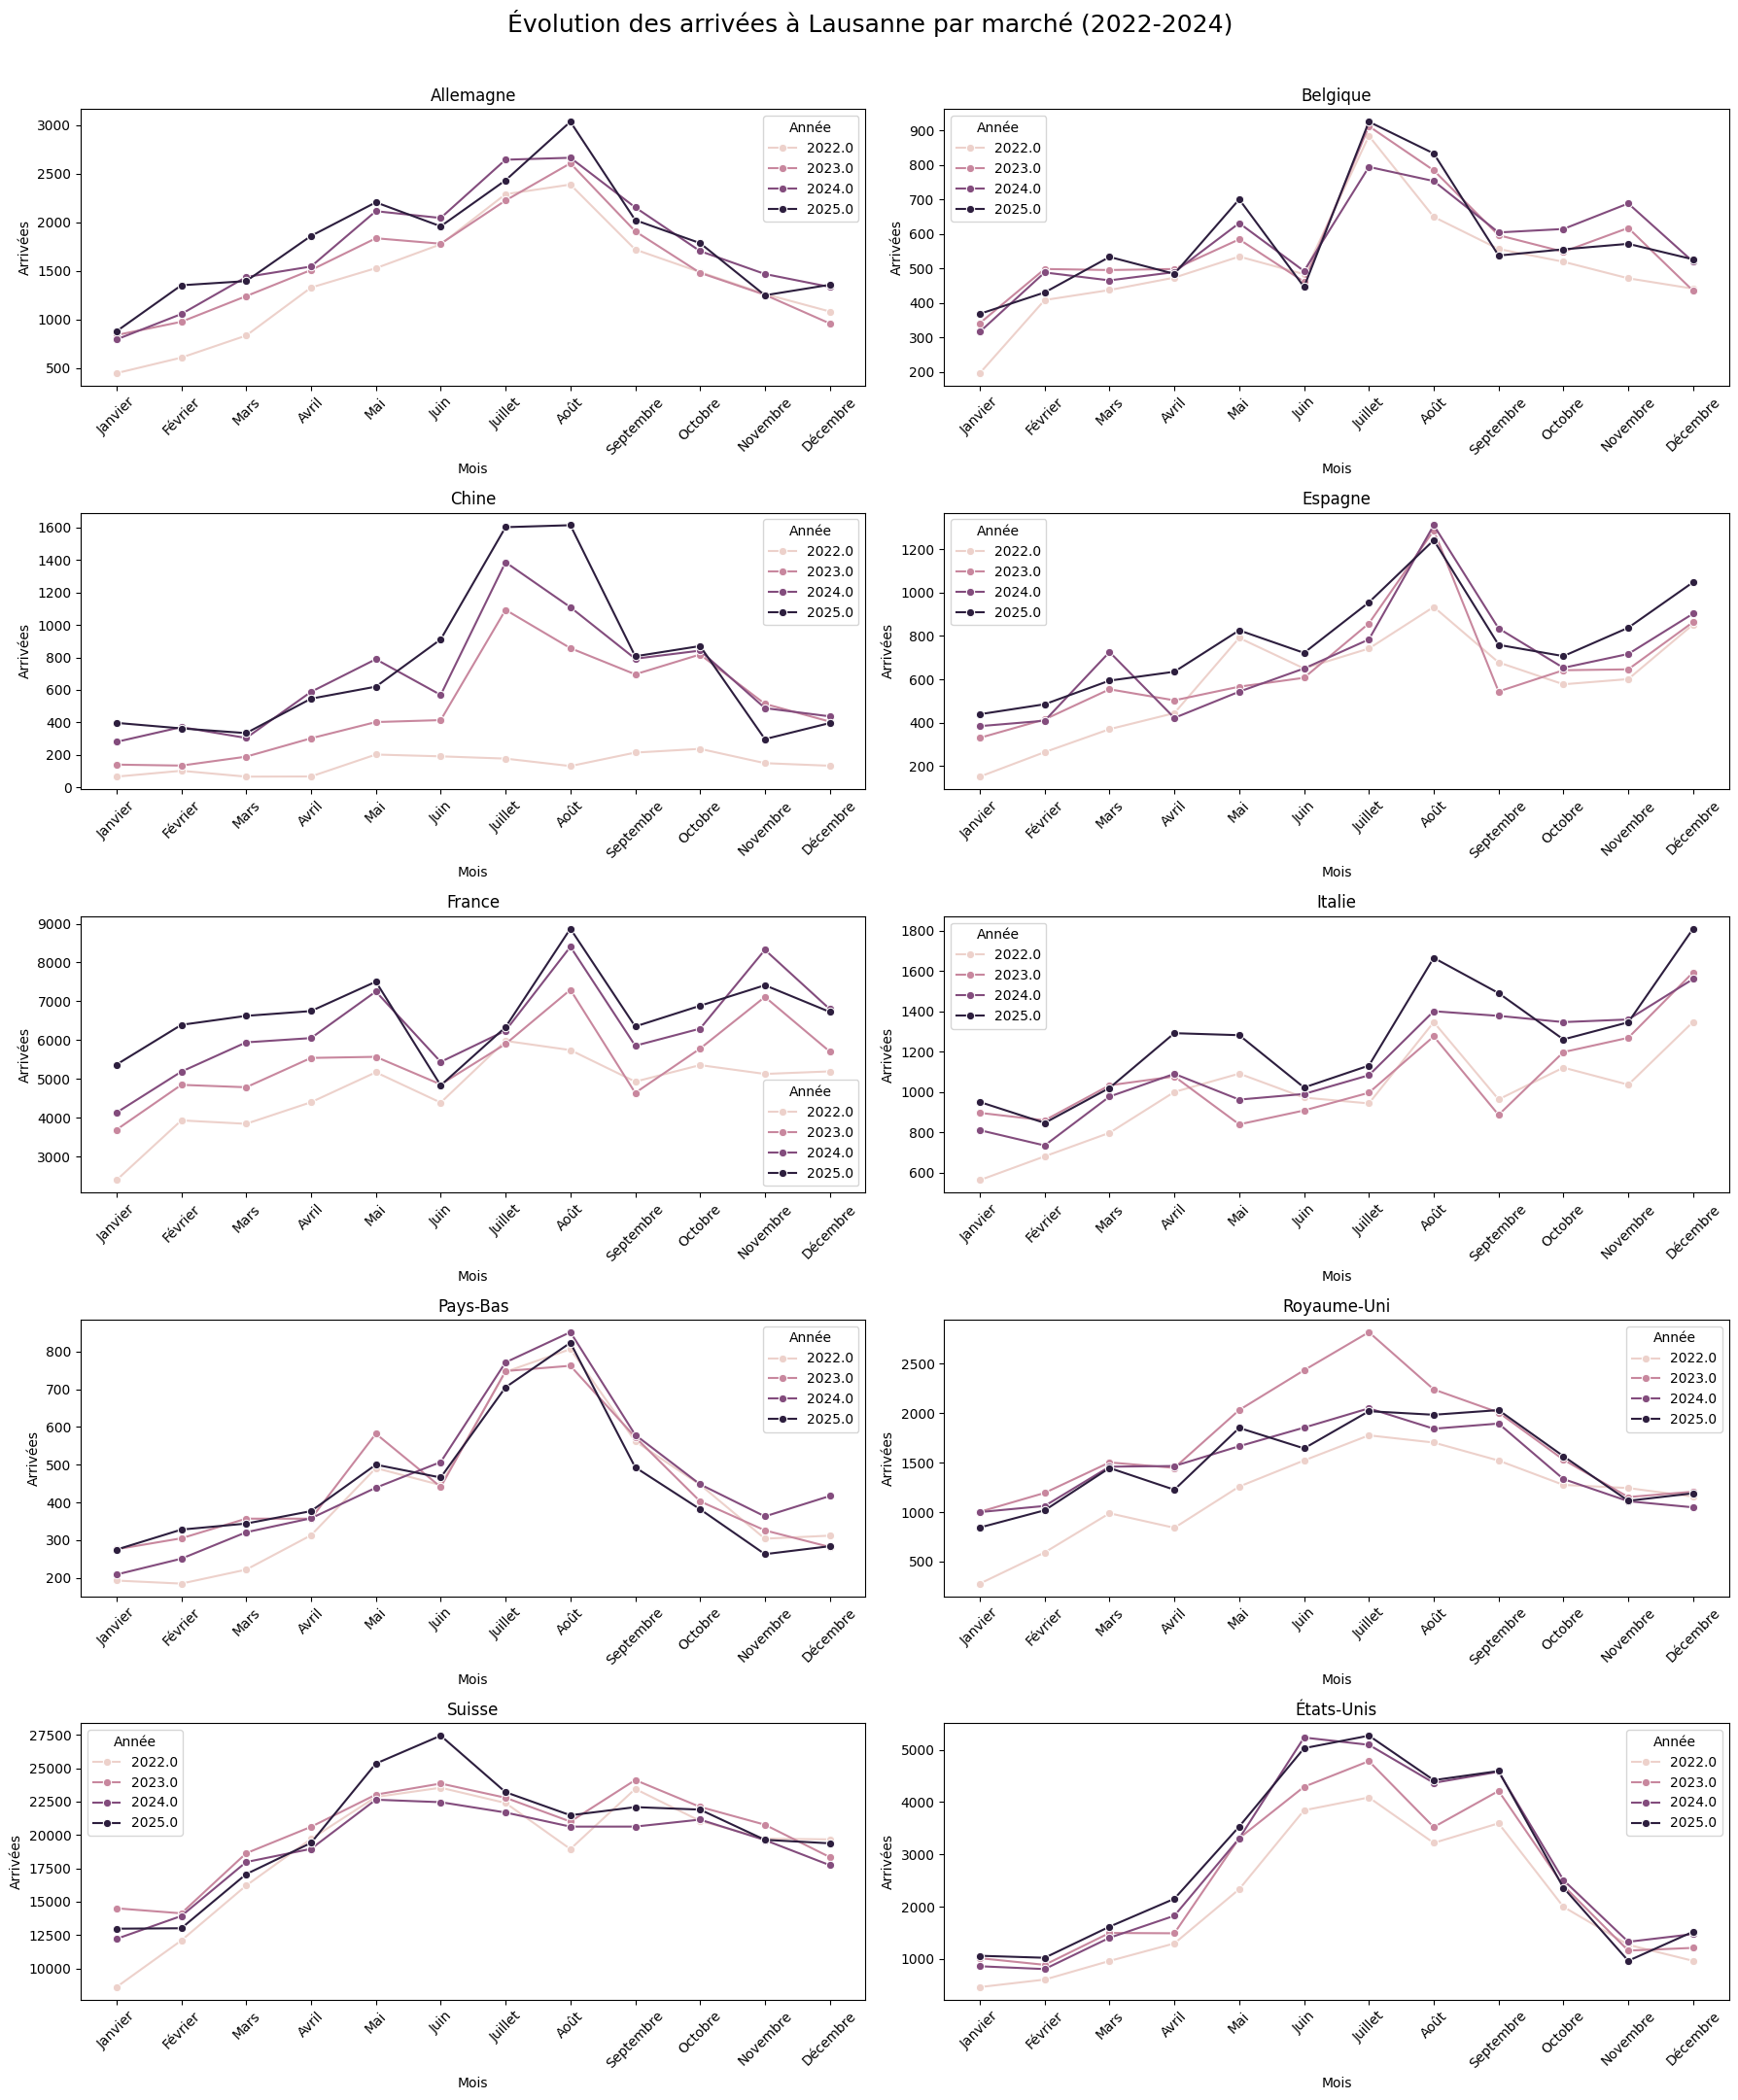

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# garder uniquement les années récentes
lausanne_recent = lausanne_top[lausanne_top["Année"].isin([2022, 2023, 2024, 2025])]

# ordre des mois
mois_ordre = [
    "Janvier","Février","Mars","Avril","Mai","Juin",
    "Juillet","Août","Septembre","Octobre","Novembre","Décembre"
]

lausanne_recent["Mois"] = pd.Categorical(
    lausanne_recent["Mois"],
    categories=mois_ordre,
    ordered=True
)

# liste des marchés
markets = lausanne_recent["Pays"].unique()

# création des 10 graphes
fig, axes = plt.subplots(5, 2, figsize=(18,22))  # ⬅️ plus grand
axes = axes.flatten()

for i, market in enumerate(markets):

    data_market = lausanne_recent[lausanne_recent["Pays"] == market]

    sns.lineplot(
        data=data_market,
        x="Mois",
        y="Arrivées",
        hue="Année",
        marker="o",
        ax=axes[i]
    )

    axes[i].set_title(market)
    axes[i].set_ylabel("Arrivées")
    axes[i].set_xlabel("Mois")

    # 🔧 rendre les mois lisibles
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle("Évolution des arrivées à Lausanne par marché (2022-2024)", fontsize=18)

# 🔧 évite que le titre chevauche
plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()

Je sais pas si vous aller réussir à run le code vu que j'ai importer depuis mon drive les base de données...

In [ ]:
df_tidy["Nuitées"] = (
    df_tidy["Nuitées"]
    .astype(str)
    .str.replace(" ", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace("\xa0", "", regex=False)
)
df_tidy["Nuitées"] = pd.to_numeric(df_tidy["Nuitées"], errors="coerce")

In [ ]:
import pandas as pd

# Reconstruire df_hesta depuis df_tidy
df_hesta = (
    df_tidy
    .groupby(["Commune", "Année", "Mois"], as_index=False)["Nuitées"]
    .sum()
)

# Reconstruire df_provenance depuis df_tidy
df_arr = df_tidy.pivot_table(
    index=["Année", "Mois", "Commune"],
    columns="Pays",
    values="Arrivées",
    aggfunc="sum"
).reset_index()
df_arr.columns = [col if col in ["Année", "Mois", "Commune"] else f"{col} Arrivées" for col in df_arr.columns]
df_arr.columns.name = None

df_nuit = df_tidy.pivot_table(
    index=["Année", "Mois", "Commune"],
    columns="Pays",
    values="Nuitées",
    aggfunc="sum"
).reset_index()
df_nuit.columns = [col if col in ["Année", "Mois", "Commune"] else f"{col} Nuitées" for col in df_nuit.columns]
df_nuit.columns.name = None

df_provenance = df_arr.merge(df_nuit, on=["Année", "Mois", "Commune"])

display(df_hesta.head())
display(df_provenance.head())

,Commune,Année,Mois,Nuitées
0,Basel,2013.0,Août,189806.0
1,Basel,2013.0,Avril,206002.0
2,Basel,2013.0,Décembre,155540.0
3,Basel,2013.0,Février,155426.0
4,Basel,2013.0,Janvier,134416.0


,Année,Mois,Commune,Afrique du Sud Arrivées,Allemagne Arrivées,Arabie saoudite Arrivées,Argentine Arrivées,Australie Arrivées,Autres Afrique Arrivées,Autres Afrique du Nord Arrivées,...,Suisse Nuitées,Suède Nuitées,Taïwan (Taipei chinois) Nuitées,Tchéquie Nuitées,Thaïlande Nuitées,Turquie Nuitées,Ukraine Nuitées,Égypte Nuitées,Émirats arabes unis Nuitées,États-Unis Nuitées
0,2013.0,Août,Basel,68.0,10025.0,129.0,35.0,497.0,112.0,35.0,...,23770.0,604.0,428.0,436.0,119.0,598.0,84.0,81.0,810.0,9473.0
1,2013.0,Août,Bern,21.0,4495.0,136.0,76.0,241.0,57.0,17.0,...,31098.0,632.0,668.0,263.0,257.0,230.0,124.0,17.0,651.0,4019.0
2,2013.0,Août,Davos,4.0,10630.0,37.0,8.0,47.0,9.0,0.0,...,35153.0,112.0,24.0,672.0,10.0,18.0,2.0,0.0,39.0,988.0
3,2013.0,Août,Genève,187.0,2858.0,6795.0,201.0,1113.0,534.0,526.0,...,26366.0,925.0,319.0,456.0,327.0,986.0,829.0,1435.0,10912.0,12593.0
4,2013.0,Août,Lausanne,48.0,1662.0,464.0,32.0,194.0,142.0,67.0,...,28611.0,388.0,186.0,146.0,131.0,512.0,223.0,143.0,1140.0,3675.0


In [ ]:
# df_hesta a déjà les bonnes colonnes, pas besoin de renommer
# Garder seulement Lausanne
df_hesta_laus = df_hesta[df_hesta['Commune'] == 'Lausanne'].copy()

display(df_hesta_laus.head(10))

,Commune,Année,Mois,Nuitées
572,Lausanne,2013.0,Août,149892.0
573,Lausanne,2013.0,Avril,113920.0
574,Lausanne,2013.0,Décembre,96700.0
575,Lausanne,2013.0,Février,97214.0
576,Lausanne,2013.0,Janvier,90266.0
577,Lausanne,2013.0,Juillet,151704.0
578,Lausanne,2013.0,Juin,150942.0
579,Lausanne,2013.0,Mai,134816.0
580,Lausanne,2013.0,Mars,121650.0
581,Lausanne,2013.0,Novembre,118250.0


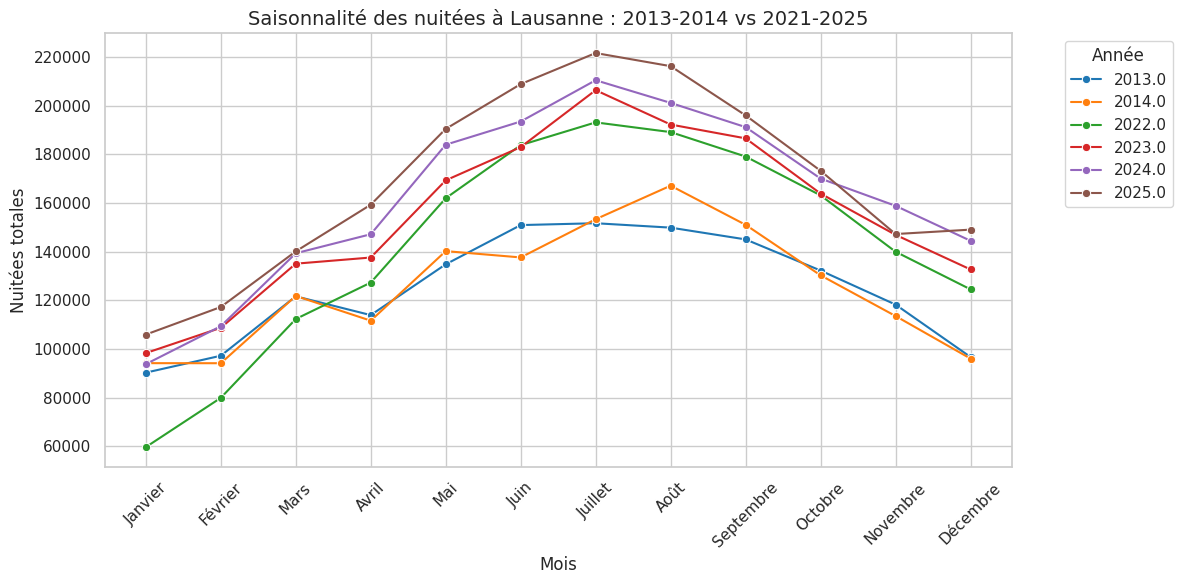

In [ ]:
# Paramètres d'affichage
sns.set_theme(style="whitegrid")

#copie pour ne pas modifier le graphe initial
df_graph1 = df_hesta_laus.copy()

# Enlever la ligne des totaux annuel
df_graph1 = df_graph1[df_graph1["Mois"] != "Total de l'année"]

# "Année" et "Nuitées" sont-elles bien reconnues comme des nombres ?
df_graph1["Année"] = pd.to_numeric(df_graph1["Année"])
df_graph1["Nuitées"] = pd.to_numeric(df_graph1["Nuitées"])

# Déterminer les années qu'on veut garder
annees_cible = [2013, 2014, 2021, 2022, 2023, 2024, 2025]
df_graph1 = df_graph1[df_graph1["Année"].isin(annees_cible)]

# Ordonner chronologiquement les mois
ordre_mois = ["Janvier", "Février", "Mars", "Avril", "Mai", "Juin", "Juillet", "Août", "Septembre", "Octobre", "Novembre", "Décembre"]
df_graph1["Mois"] = pd.Categorical(df_graph1["Mois"], categories=ordre_mois, ordered=True)

#  Création de la figure
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_graph1, x="Mois", y="Nuitées", hue="Année", palette="tab10", marker="o")
plt.title("Saisonnalité des nuitées à Lausanne : 2013-2014 vs 2021-2025", fontsize=14)
plt.xlabel("Mois", fontsize=12)
plt.ylabel("Nuitées totales", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Année", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()

In [ ]:
# df_provenance a déjà les bonnes colonnes, pas besoin de renommer
# Suppression des lignes "Total de l'année"
df_provenance = df_provenance[df_provenance["Mois"] != "Total de l'année"]

df_provenance_laus = df_provenance[df_provenance["Commune"] == "Lausanne"].copy()
df_provenance_laus.head()

,Année,Mois,Commune,Afrique du Sud Arrivées,Allemagne Arrivées,Arabie saoudite Arrivées,Argentine Arrivées,Australie Arrivées,Autres Afrique Arrivées,Autres Afrique du Nord Arrivées,...,Suisse Nuitées,Suède Nuitées,Taïwan (Taipei chinois) Nuitées,Tchéquie Nuitées,Thaïlande Nuitées,Turquie Nuitées,Ukraine Nuitées,Égypte Nuitées,Émirats arabes unis Nuitées,États-Unis Nuitées
4,2013.0,Août,Lausanne,48.0,1662.0,464.0,32.0,194.0,142.0,67.0,...,28611.0,388.0,186.0,146.0,131.0,512.0,223.0,143.0,1140.0,3675.0
17,2013.0,Avril,Lausanne,19.0,1302.0,41.0,37.0,136.0,104.0,105.0,...,21832.0,564.0,87.0,110.0,248.0,306.0,250.0,99.0,246.0,3037.0
30,2013.0,Décembre,Lausanne,52.0,806.0,23.0,22.0,122.0,68.0,53.0,...,21393.0,228.0,21.0,111.0,81.0,278.0,130.0,125.0,216.0,1657.0
43,2013.0,Février,Lausanne,22.0,1063.0,24.0,40.0,119.0,94.0,60.0,...,18261.0,475.0,58.0,138.0,86.0,428.0,277.0,86.0,199.0,1988.0
56,2013.0,Janvier,Lausanne,31.0,891.0,37.0,53.0,178.0,142.0,44.0,...,16799.0,338.0,60.0,131.0,39.0,255.0,215.0,81.0,186.0,2164.0


/tmp/ipykernel_3076/4284237818.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_groupe_arr = df_recent_arr.groupby(["Mois", "Marché_Regroupé"])["Arrivées"].mean().unstack()


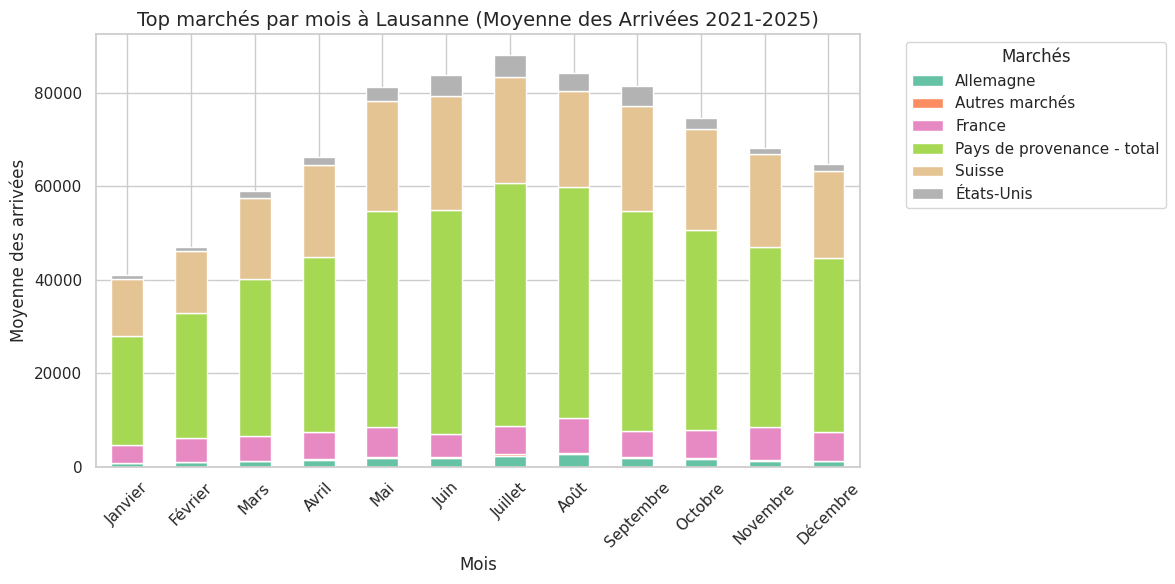

In [ ]:
# Isoler colonnes arrivées
colonnes_arrivees = [col for col in df_provenance_laus.columns if str(col).endswith("Arrivées") and col != "Total Arrivées"]
df_arr = df_provenance_laus[["Année", "Mois"] + colonnes_arrivees].copy()

# convertir en nbres
for col in colonnes_arrivees:
    df_arr[col] = pd.to_numeric(df_arr[col], errors="coerce").fillna(0)

# Melt tableau
df_long_arr = pd.melt(df_arr, id_vars=["Année", "Mois"], var_name="Marché", value_name="Arrivées")
df_long_arr["Marché"] = df_long_arr["Marché"].str.replace(" Arrivées", "")

# Définir les années qu'on veut analyser
df_long_arr["Année"] = pd.to_numeric(df_long_arr["Année"])
df_recent_arr = df_long_arr[df_long_arr["Année"].isin([2021, 2022, 2023, 2024, 2025])].copy()

top_5_marches = df_recent_arr.groupby("Marché")["Arrivées"].sum().nlargest(5).index.tolist()
df_recent_arr["Marché_Regroupé"] = df_recent_arr["Marché"].apply(lambda x: x if x in top_5_marches else "Autres marchés")
ordre_mois = ["Janvier", "Février", "Mars", "Avril", "Mai", "Juin", "Juillet", "Août", "Septembre", "Octobre", "Novembre", "Décembre"]
df_recent_arr["Mois"] = pd.Categorical(df_recent_arr["Mois"], categories=ordre_mois, ordered=True)

# Créer graphique
df_groupe_arr = df_recent_arr.groupby(["Mois", "Marché_Regroupé"])["Arrivées"].mean().unstack()
df_groupe_arr.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="Set2")

plt.title("Top marchés par mois à Lausanne (Moyenne des Arrivées 2021-2025)", fontsize=14)
plt.xlabel("Mois", fontsize=12)
plt.ylabel("Moyenne des arrivées", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Marchés", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
donnees_tableau = []
df_provenance_laus["Année"] = pd.to_numeric(df_provenance_laus["Année"], errors="coerce")
# On filtre le dataframe d'origine pour la même période (2021-2025)
df_prov_recent = df_provenance_laus[df_provenance_laus["Année"].isin([2021, 2022, 2023, 2024, 2025])].copy()

for marche in top_5_marches:
    col_arr = f"{marche} Arrivées"
    col_nuit = f"{marche} Nuitées"

    # calcule de la moyenne mensuelle des arrivées et des nuitées
    moyenne_arr = pd.to_numeric(df_prov_recent[col_arr], errors="coerce").mean()
    moyenne_nuit = pd.to_numeric(df_prov_recent[col_nuit], errors="coerce").mean()

    # Calcule DMS (durée moyenne de séjour)
    dms = moyenne_nuit / moyenne_arr if moyenne_arr > 0 else 0

    donnees_tableau.append({
        "Marché (Top 5)": marche,
        "Arrivées Moyennes / mois": round(moyenne_arr, 0),
        "Nuitées Moyennes / mois": round(moyenne_nuit, 0),
        "Durée Moyenne de Séjour (Jours)": round(dms, 2)
    })


df_recapitulatif = pd.DataFrame(donnees_tableau)
display(df_recapitulatif)

,Marché (Top 5),Arrivées Moyennes / mois,Nuitées Moyennes / mois,Durée Moyenne de Séjour (Jours)
0,Pays de provenance - total,40194.0,78586.0,1.96
1,Suisse,19682.0,35428.0,1.80
2,France,5796.0,9802.0,1.69
3,États-Unis,2517.0,5782.0,2.30
4,Allemagne,1622.0,3217.0,1.98


In [ ]:
import pandas as pd

# définir les saisons
dico_saisons = {
    "Janvier": "3. Basse", "Février": "3. Basse", "Mars": "3. Basse", "Novembre": "3. Basse", "Décembre": "3. Basse",
    "Avril": "2. Moyenne", "Mai": "2. Moyenne", "Octobre": "2. Moyenne",
    "Juin": "1. Haute", "Juillet": "1. Haute", "Août": "1. Haute", "Septembre": "1. Haute"
}

df_saisons = df_provenance_laus.copy()
df_saisons["Saison"] = df_saisons["Mois"].map(dico_saisons)
df_saisons["Année"] = pd.to_numeric(df_saisons["Année"], errors="coerce")
df_recent_saisons = df_saisons[df_saisons["Année"].isin([2021, 2022, 2023, 2024, 2025])].copy()

tous_les_marches = [col.replace(" Arrivées", "") for col in df_provenance_laus.columns if str(col).endswith(" Arrivées") and col != "Total Arrivées"]


resultats_finaux = []
for saison in ["1. Haute", "2. Moyenne", "3. Basse"]:
    df_filtre = df_recent_saisons[df_recent_saisons["Saison"] == saison]

    donnees_saison_actuelle = []
    for marche in tous_les_marches:
        col_arr = f"{marche} Arrivées"
        col_nuit = f"{marche} Nuitées"
        # Moyennes mensuelles pendant cette saison
        moyenne_arr = pd.to_numeric(df_filtre[col_arr], errors="coerce").mean()
        moyenne_nuit = pd.to_numeric(df_filtre[col_nuit], errors="coerce").mean()
        # On ne garde que les marchés qui ont eu des visiteurs
        if moyenne_arr > 0:
            dms = moyenne_nuit / moyenne_arr
            donnees_saison_actuelle.append({
                "Saison": saison.replace("1. ", "").replace("2. ", "").replace("3. ", ""), # On nettoie le nom
                "Marché": marche,
                "Arrivées Moy. / mois": round(moyenne_arr, 0),
                "Nuitées Moy. / mois": round(moyenne_nuit, 0),
                "Durée de Séjour (DMS)": round(dms, 2)
            })

    df_stats_saison = pd.DataFrame(donnees_saison_actuelle)

    # Top 10
    top_10 = df_stats_saison.sort_values(by="Nuitées Moy. / mois", ascending=False).head(10)
    resultats_finaux.append(top_10)

df_tableau_saisons = pd.concat(resultats_finaux).reset_index(drop=True)
display(df_tableau_saisons.style.set_properties(**{"text-align": "center", "border": "1px solid black"}))

,Saison,Marché,Arrivées Moy. / mois,Nuitées Moy. / mois,Durée de Séjour (DMS)
0,Haute,Pays de provenance - total,49113.000000,98532.000000,2.010000
1,Haute,Suisse,22482.000000,41631.000000,1.850000
2,Haute,France,6005.000000,10467.000000,1.740000
3,Haute,États-Unis,4383.000000,9823.000000,2.240000
4,Haute,Allemagne,2228.000000,4340.000000,1.950000
5,Haute,Royaume-Uni,1960.000000,4147.000000,2.120000
6,Haute,Italie,1153.000000,2190.000000,1.900000
7,Haute,Espagne,847.000000,1856.000000,2.190000
8,Haute,Arabie saoudite,424.000000,1534.000000,3.610000
9,Haute,Belgique,669.000000,1391.000000,2.080000


/tmp/ipykernel_3076/2319489167.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_10_trie_dms, x="DMS", y="Marché", palette="mako")


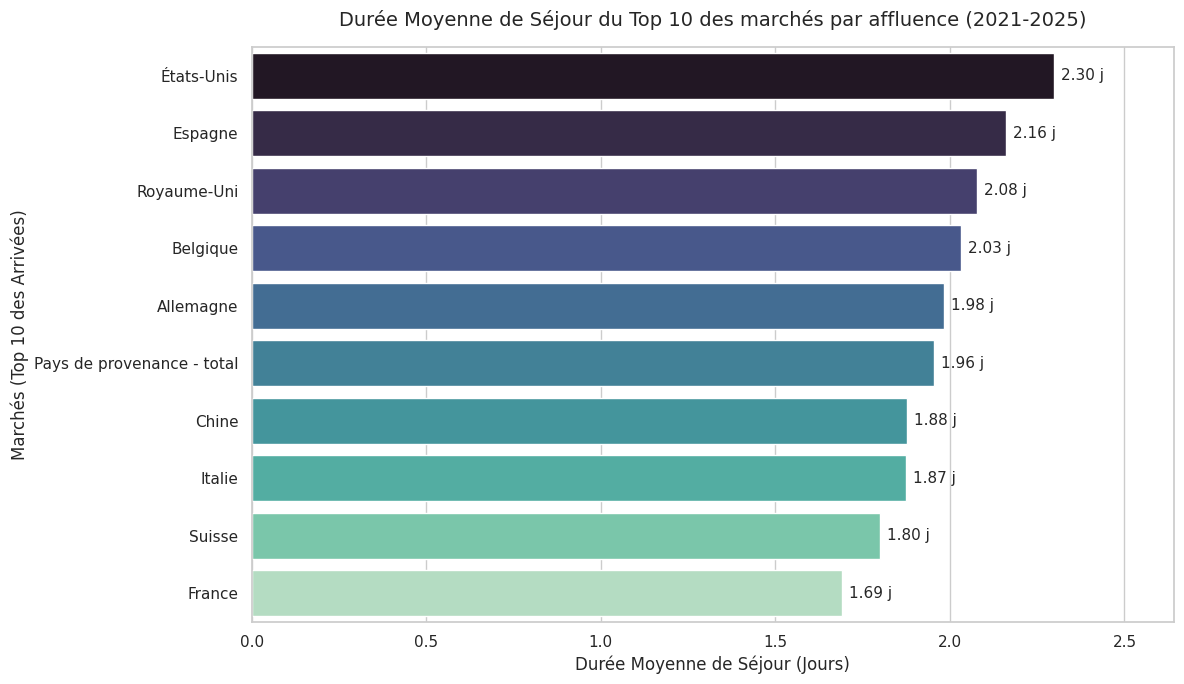

In [ ]:
df_prov_recent = df_provenance_laus.copy()
df_prov_recent["Année"] = pd.to_numeric(df_prov_recent["Année"], errors="coerce")
df_prov_recent = df_prov_recent[df_prov_recent["Année"].isin([2021, 2022, 2023, 2024, 2025])]

#Identifier tous les marchés disponibles
tous_les_marches = [col.replace(" Arrivées", "") for col in df_provenance_laus.columns if str(col).endswith(" Arrivées") and col != "Total Arrivées"]

donnees_marches = []

# Calculer les moyennes par marché
for marche in tous_les_marches:
    col_arr = f"{marche} Arrivées"
    col_nuit = f"{marche} Nuitées"

    moyenne_arr = pd.to_numeric(df_prov_recent[col_arr], errors="coerce").mean()
    moyenne_nuit = pd.to_numeric(df_prov_recent[col_nuit], errors="coerce").mean()

    if moyenne_arr > 0:
        dms = moyenne_nuit / moyenne_arr
        donnees_marches.append({
            "Marché": marche,
            "Arrivées Moyennes": moyenne_arr,
            "DMS": dms
        })

df_stats = pd.DataFrame(donnees_marches)

#  Top 10 selon arrivées
top_10_arrivees = df_stats.sort_values(by="Arrivées Moyennes", ascending=False).head(10).copy()

# DMS
top_10_trie_dms = top_10_arrivees.sort_values(by="DMS", ascending=False)

# Création du graphique
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")
ax = sns.barplot(data=top_10_trie_dms, x="DMS", y="Marché", palette="mako")
plt.title("Durée Moyenne de Séjour du Top 10 des marchés par affluence (2021-2025)", fontsize=14, pad=15)
plt.xlabel("Durée Moyenne de Séjour (Jours)", fontsize=12)
plt.ylabel("Marchés (Top 10 des Arrivées)", fontsize=12)

for p in ax.patches:
    ax.annotate(f"{p.get_width():.2f} j",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha="left", va="center",
                xytext=(5, 0),
                textcoords="offset points",
                fontsize=11)
plt.xlim(0, top_10_trie_dms["DMS"].max() * 1.15)
plt.tight_layout()
plt.show()

arrivée totales tout pays confondu (est ce que c'est tout pays confondus ou top marché??)

In [ ]:
# Colonnes arrivées et nuitées
cols_arrivees = [col for col in df_provenance_laus.columns if 'Arrivées' in col]
cols_nuitees = [col for col in df_provenance_laus.columns if 'Nuitées' in col]

# Total tous pays par ligne
total_arrivees = df_provenance_laus[cols_arrivees].sum(axis=1)
total_nuitees = df_provenance_laus[cols_nuitees].sum(axis=1)

# Durée moyenne de séjour tous pays confondus
duree_moyenne = total_nuitees.sum() / total_arrivees.sum()

print(f"Durée moyenne de séjour (tous pays confondus) : {duree_moyenne:.2f} jours")

Durée moyenne de séjour (tous pays confondus) : 2.00 jours


In [ ]:
# Vérifier sans arrondi
duree_moyenne = total_nuitees.sum() / total_arrivees.sum()
print(f"Valeur exacte : {duree_moyenne}")  # Affiche tous les décimales

# Vérifier les totaux bruts
print(f"Total nuitées : {total_nuitees.sum():,.0f}")
print(f"Total arrivées : {total_arrivees.sum():,.0f}")

Valeur exacte : 1.9996507924711595
Total nuitées : 19,480,714
Total arrivées : 9,742,058


comparer lausanne avec les autres villes suisse

In [ ]:
df_tidy[df_tidy["Pays"] == "Pays de provenance - total"]

,Année,Mois,Commune,Commune_nom,Pays,Arrivées,Nuitées,Request
51,2013.0,Août,Basel,Basel,Pays de provenance - total,51329.0,94903.0,NaN
125,2013.0,Août,Bern,Bern,Pays de provenance - total,45192.0,78139.0,NaN
199,2013.0,Août,Davos,Davos,Pays de provenance - total,29986.0,92045.0,NaN
273,2013.0,Août,Genève,Genève,Pays de provenance - total,89560.0,192240.0,NaN
347,2013.0,Août,Lausanne,Lausanne,Pays de provenance - total,36706.0,74946.0,NaN
...,...,...,...,...,...,...,...,...
137247,2025.0,Total de l'année,Nendaz,Nendaz,Pays de provenance - total,22790.0,40655.0,NaN
137321,2025.0,Total de l'année,Saas-Fee,Zermatt,Pays de provenance - total,97248.0,271313.0,NaN
137395,2025.0,Total de l'année,Samedan,St Moritz,Pays de provenance - total,25210.0,52632.0,NaN
137469,2025.0,Total de l'année,St. Gallen,St Gallen,Pays de provenance - total,164156.0,310568.0,NaN


In [ ]:
print(df_tidy["Commune_nom"].unique())

['Basel' 'Bern' 'Davos' 'Genève' 'Lausanne' 'Locarno' 'Luzern' 'Montreux'
 'Nendaz' 'Zermatt' 'St Moritz' 'St Gallen' 'Zürich']


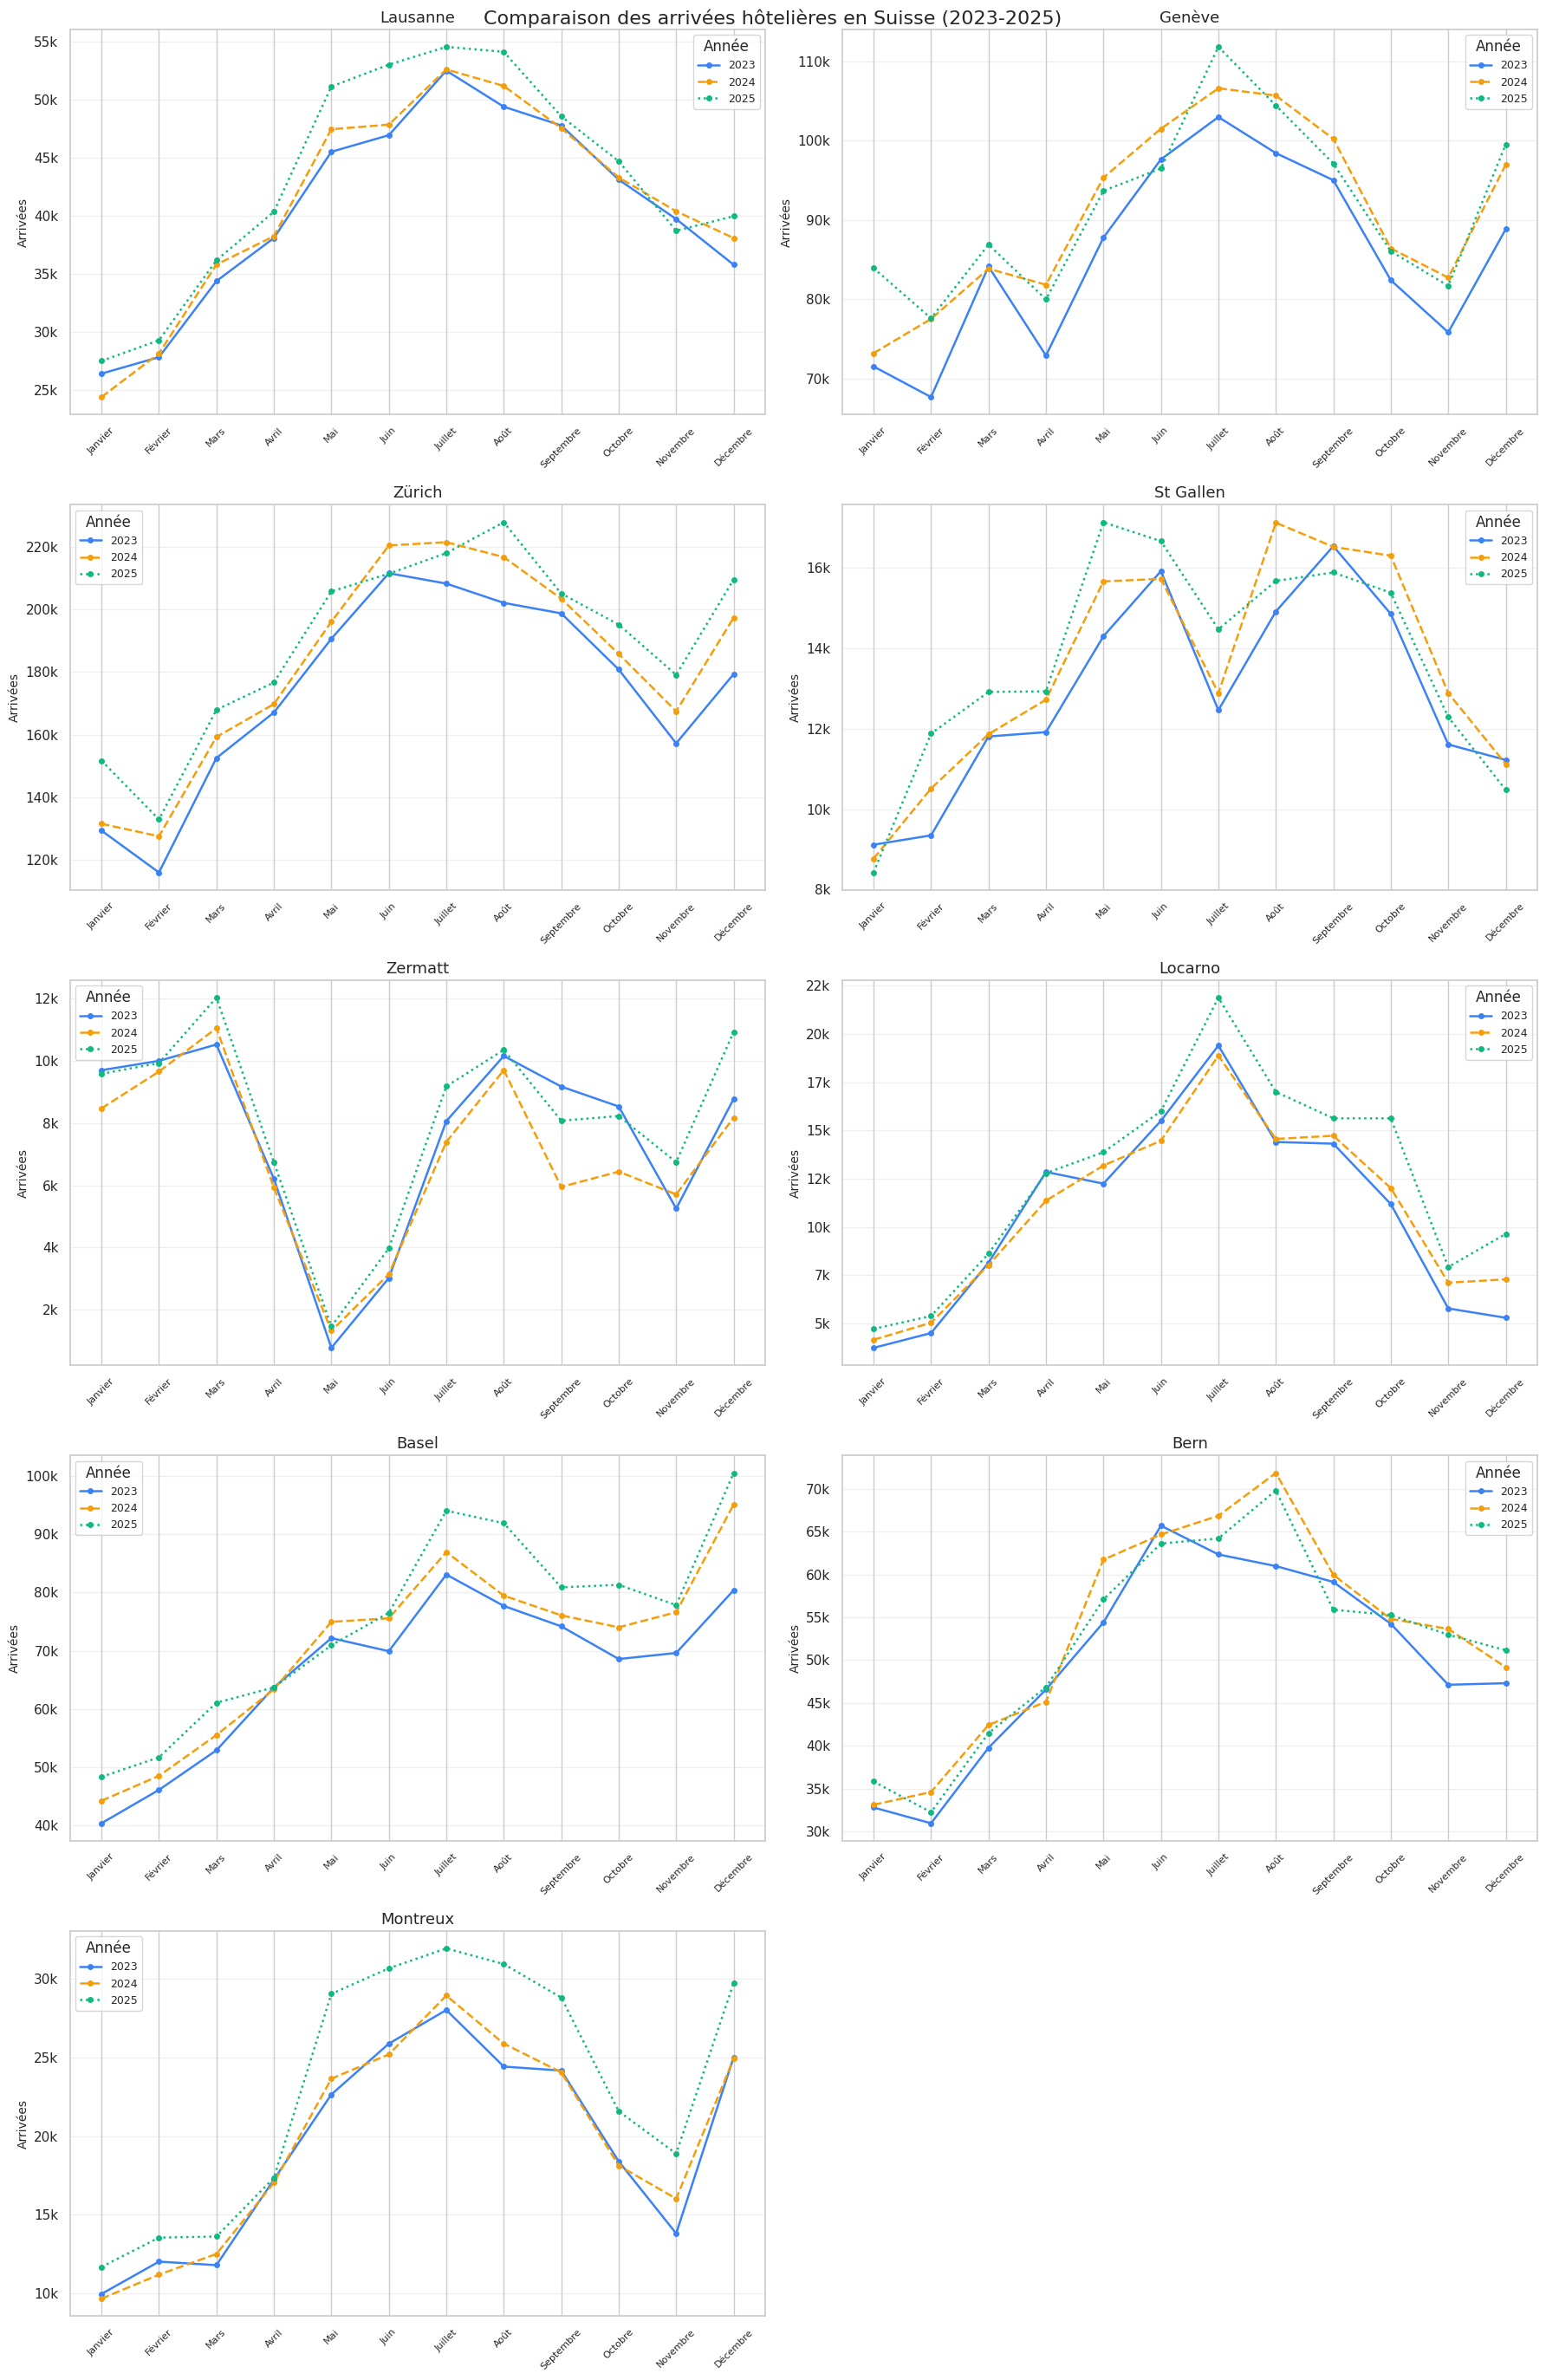

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

villes_cibles = [
    "Lausanne", "Genève", "Zürich", "St Gallen",
    "Zermatt", "Locarno", "Basel", "Bern", "Montreux"
]

annees_cibles = [2023, 2024, 2025]

ordre_mois = [
    "Janvier","Février","Mars","Avril","Mai","Juin",
    "Juillet","Août","Septembre","Octobre","Novembre","Décembre"
]

# filtrage
df_comp = df_tidy[
    (df_tidy["Pays"] == "Pays de provenance - total") &
    (df_tidy["Commune_nom"].isin(villes_cibles)) &
    (df_tidy["Année"].isin(annees_cibles)) &
    (df_tidy["Mois"] != "Total de l'année")
].copy()

# conversions
df_comp["Mois"] = pd.Categorical(
    df_comp["Mois"],
    categories=ordre_mois,
    ordered=True
)

df_comp["Année"] = pd.to_numeric(df_comp["Année"])

df_comp["Arrivées"] = pd.to_numeric(
    df_comp["Arrivées"],
    errors="coerce"
)

# styles
couleurs = {
    2023: "#3b82f6",
    2024: "#f59e0b",
    2025: "#10b981"
}

styles = {
    2023: "-",
    2024: "--",
    2025: ":"
}

# ===== FIGURE =====

fig, axes = plt.subplots(5, 2, figsize=(18, 28))
axes = axes.flatten()

for i, ville in enumerate(villes_cibles):

    ax = axes[i]

    df_ville = df_comp[
        df_comp["Commune_nom"] == ville
    ]

    for annee in annees_cibles:

        df_an = df_ville[
            df_ville["Année"] == annee
        ].sort_values("Mois")

        if df_an.empty:
            print(f"⚠️ Aucune donnée : {ville} / {annee}")
            continue

        ax.plot(
            df_an["Mois"],
            df_an["Arrivées"],
            label=str(annee),
            color=couleurs[annee],
            linestyle=styles[annee],
            marker="o",
            markersize=4,
            linewidth=1.8
        )

    ax.set_title(ville, fontsize=13)

    ax.set_ylabel("Arrivées", fontsize=10)

    ax.tick_params(
        axis="x",
        rotation=45,
        labelsize=8
    )

    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda x, _: f"{int(x/1000)}k"
            if x >= 1000 else str(int(x))
        )
    )

    ax.legend(title="Année", fontsize=9)

    ax.grid(axis="y", alpha=0.3)

# supprimer le graphique vide
for j in range(len(villes_cibles), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Comparaison des arrivées hôtelières en Suisse (2023-2025)",
    fontsize=16
)

plt.tight_layout()

plt.show()

In [ ]:
import requests
import pandas as pd
from io import StringIO

url = "https://www.pxweb.bfs.admin.ch/api/v1/fr/px-x-1003020000_101/px-x-1003020000_101.px"

data = {
    "query": [
        {
            "code": "Jahr",
            "selection": {
                "filter": "item",
                "values": ["2023", "2024", "2025"]
            }
        },
        {
            "code": "Gemeinde",
            "selection": {
                "filter": "all",
                "values": ["*"]
            }
        }
    ],
    "response": {
        "format": "csv"
    }
}

# requête API
r = requests.post(url, json=data, timeout=120)

print(r.status_code)

# lecture CSV
df = pd.read_csv(StringIO(r.text))

# conversion numérique
df["Arrivées"] = pd.to_numeric(df["Arrivées"], errors="coerce")
df["Nuitées"] = pd.to_numeric(df["Nuitées"], errors="coerce")

# total suisse annuel
df_all_annuel = (
    df.groupby("Année")[["Arrivées", "Nuitées"]]
      .sum()
      .reset_index()
)

print(df_all_annuel)

200
   Année    Arrivées     Nuitées
0   2023  16462926.0  33316537.0
1   2024  17084104.0  34281628.0
2   2025  17592547.0  35201445.0


In [ ]:
df_market_share = ...

    Année Commune_nom  Arrivées_ville  Arrivées_suisse  Market_share
0  2023.0       Basel        798666.0       16462926.0      4.851300
1  2023.0        Bern        601276.0       16462926.0      3.652303
2  2023.0      Genève       1025412.0       16462926.0      6.228613
3  2023.0    Lausanne        487583.0       16462926.0      2.961703
4  2023.0     Locarno        127309.0       16462926.0      0.773307


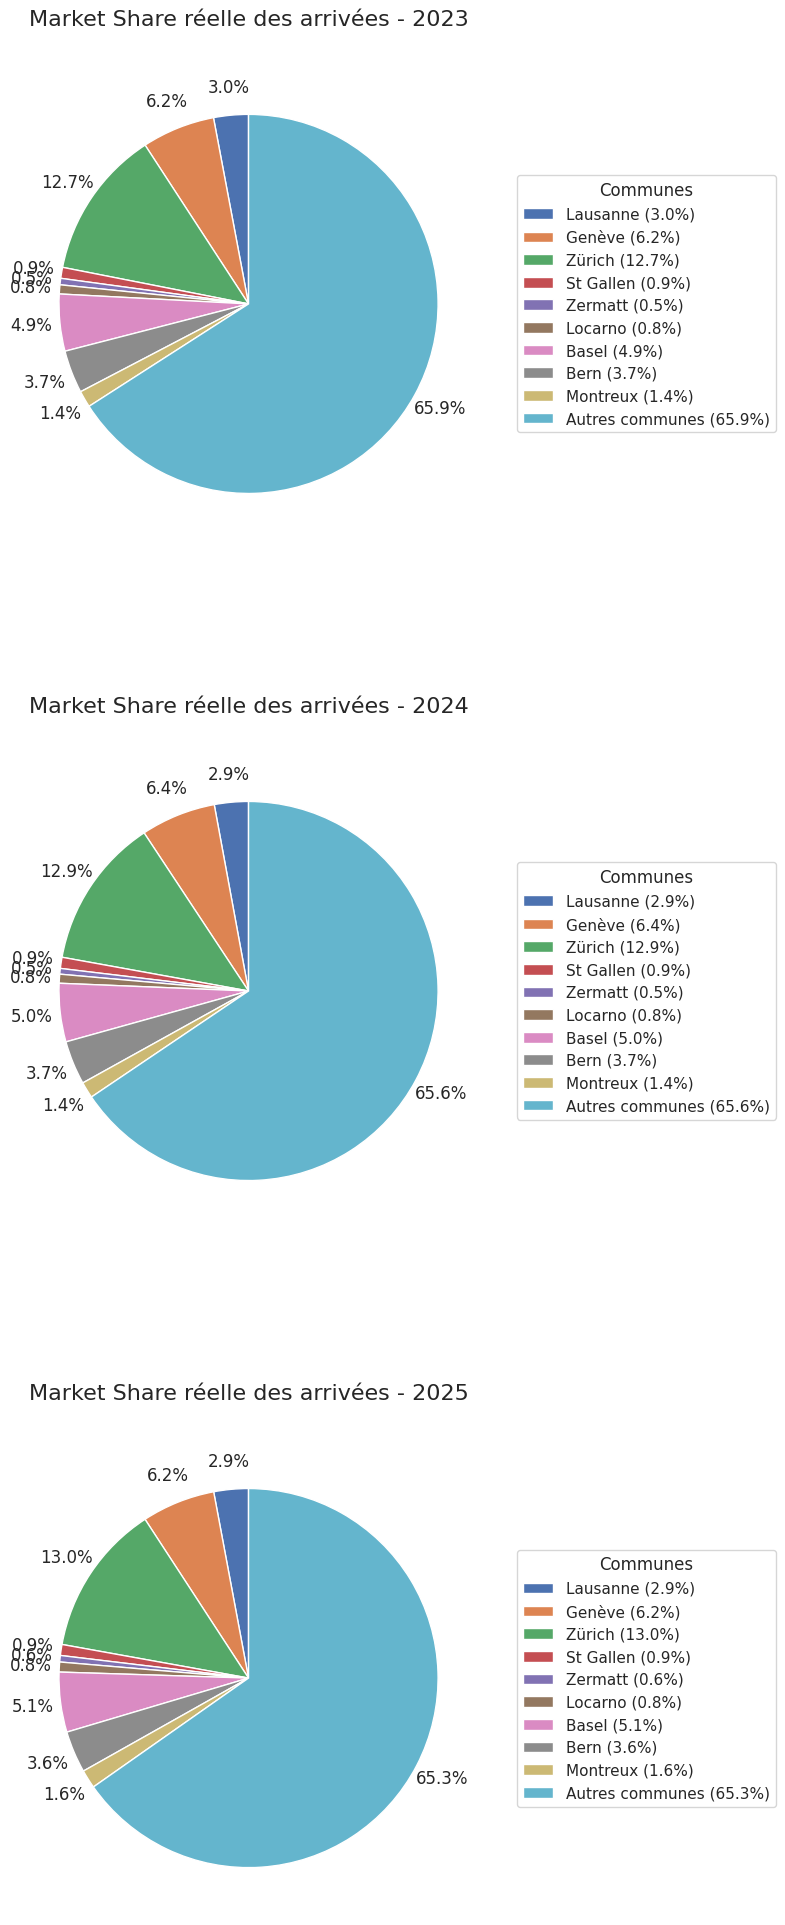

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# villes étudiées
villes_cibles = [
    "Lausanne", "Genève", "Zürich", "St Gallen",
    "Zermatt", "Locarno", "Basel", "Bern", "Montreux"
]

annees_cibles = [2023, 2024, 2025]

# ===== FILTRAGE =====

df_market_share_arrivees = df_tidy[
    (df_tidy["Pays"] == "Pays de provenance - total") &
    (df_tidy["Commune_nom"].isin(villes_cibles)) &
    (df_tidy["Année"].isin(annees_cibles)) &
    (df_tidy["Mois"] == "Total de l'année")
].copy()

# conversions numériques
df_market_share_arrivees["Arrivées"] = pd.to_numeric(
    df_market_share_arrivees["Arrivées"],
    errors="coerce"
)

df_market_share_arrivees["Année"] = pd.to_numeric(
    df_market_share_arrivees["Année"]
)

# ===== TOTAL ARRIVÉES PAR VILLE =====

df_market_share_arrivees = (
    df_market_share_arrivees.groupby(
        ["Année", "Commune_nom"]
    )["Arrivées"]
    .sum()
    .reset_index()
)

# ===== MERGE TOTAL SUISSE =====

df_market_share_arrivees = df_market_share_arrivees.merge(
    df_all_annuel[["Année", "Arrivées"]],
    on="Année",
    suffixes=("_ville", "_suisse")
)

# ===== MARKET SHARE ARRIVÉES =====

df_market_share_arrivees["Market_share"] = (
    df_market_share_arrivees["Arrivées_ville"] /
    df_market_share_arrivees["Arrivées_suisse"]
) * 100

print(df_market_share_arrivees.head())

# ===== PIE CHARTS AMÉLIORÉS =====

fig, axes = plt.subplots(3, 1, figsize=(12, 24))

for i, annee in enumerate(annees_cibles):

    df_an = df_market_share_arrivees[
        df_market_share_arrivees["Année"] == annee
    ].copy()

    # ordre forcé
    ordre_villes = [
        "Lausanne", "Genève", "Zürich", "St Gallen",
        "Zermatt", "Locarno", "Basel", "Bern", "Montreux"
    ]

    df_an["Commune_nom"] = pd.Categorical(
        df_an["Commune_nom"],
        categories=ordre_villes,
        ordered=True
    )

    df_an = df_an.sort_values("Commune_nom")

    # ajout autres communes
    reste = 100 - df_an["Market_share"].sum()

    labels = list(df_an["Commune_nom"]) + ["Autres communes"]
    values = list(df_an["Market_share"]) + [reste]

    # pie chart
    wedges, texts, autotexts = axes[i].pie(
        values,
        labels=None,
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=1.15
    )

    axes[i].set_title(
        f"Market Share réelle des arrivées - {annee}",
        fontsize=16,
        pad=30
    )

    # légende
    legend_labels = [
        f"{label} ({value:.1f}%)"
        for label, value in zip(labels, values)
    ]

    axes[i].legend(
        wedges,
        legend_labels,
        title="Communes",
        loc="center left",
        bbox_to_anchor=(1.05, 0.5),
        fontsize=11
    )

plt.subplots_adjust(hspace=0.45)

plt.show()

Rebolote mais analyse des nuitée en market share

    Année Commune_nom  Nuitées_ville  Nuitées_suisse  Market_share
0  2023.0       Basel      1463684.0      33316537.0      4.393266
1  2023.0        Bern      1044046.0      33316537.0      3.133717
2  2023.0      Genève      2252671.0      33316537.0      6.761420
3  2023.0    Lausanne       930443.0      33316537.0      2.792736
4  2023.0     Locarno       275214.0      33316537.0      0.826058


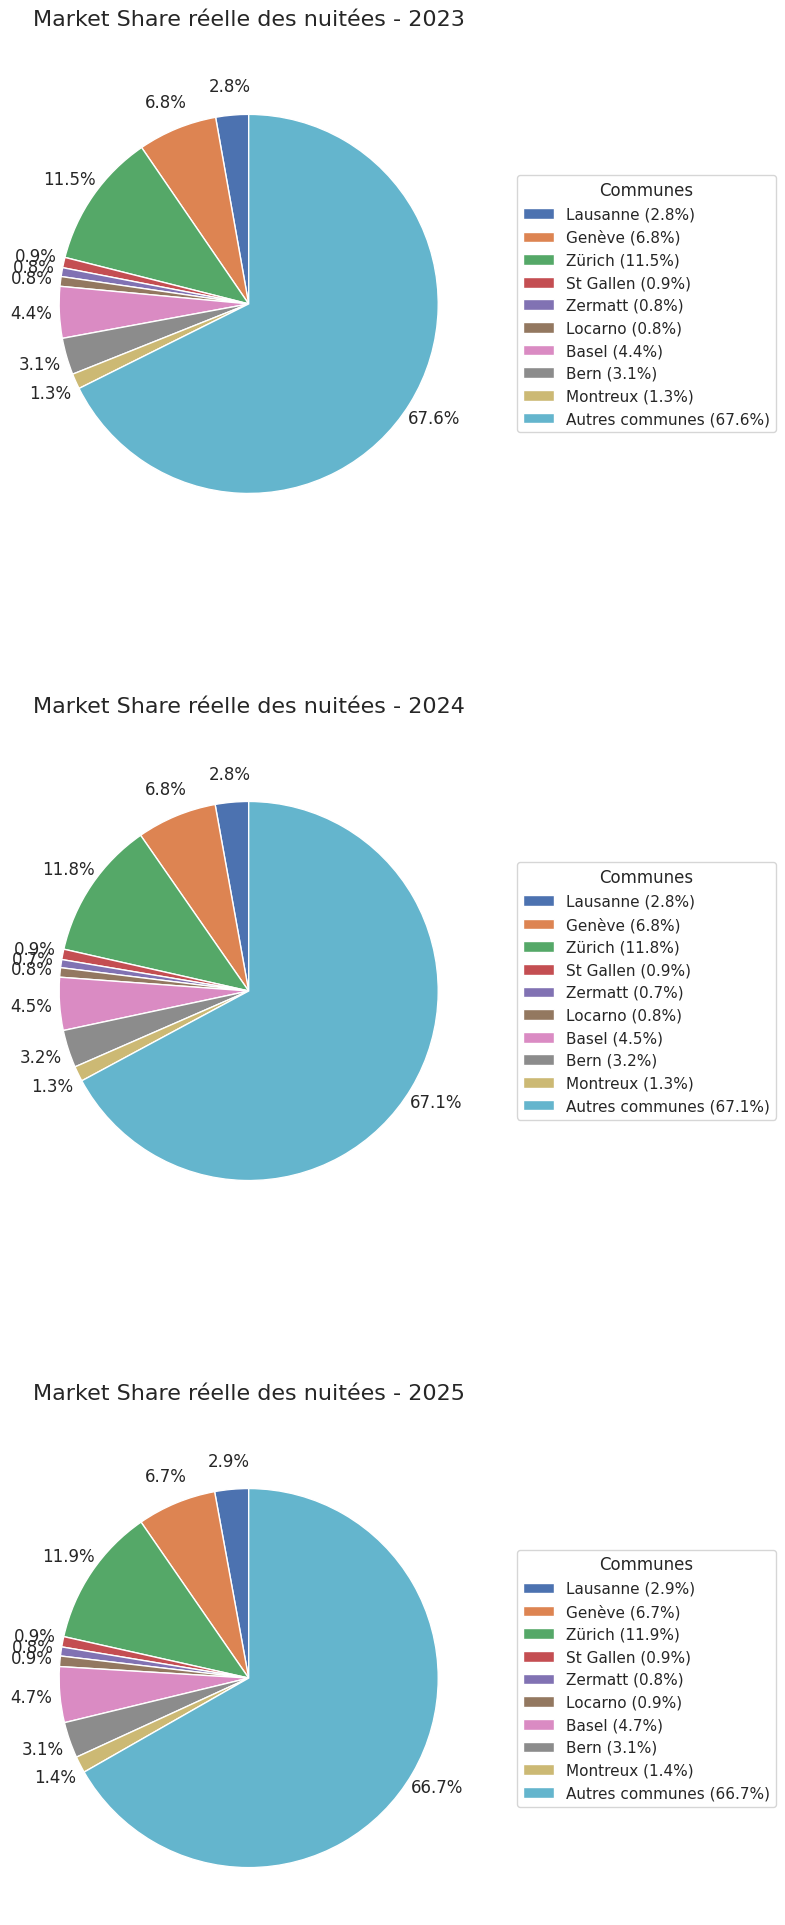

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# villes étudiées
villes_cibles = [
    "Lausanne", "Genève", "Zürich", "St Gallen",
    "Zermatt", "Locarno", "Basel", "Bern", "Montreux"
]

annees_cibles = [2023, 2024, 2025]

# ===== FILTRAGE =====

df_market_share_nuitees = df_tidy[
    (df_tidy["Pays"] == "Pays de provenance - total") &
    (df_tidy["Commune_nom"].isin(villes_cibles)) &
    (df_tidy["Année"].isin(annees_cibles)) &
    (df_tidy["Mois"] == "Total de l'année")
].copy()

# conversions numériques
df_market_share_nuitees["Nuitées"] = pd.to_numeric(
    df_market_share_nuitees["Nuitées"],
    errors="coerce"
)

df_market_share_nuitees["Année"] = pd.to_numeric(
    df_market_share_nuitees["Année"]
)

# ===== TOTAL NUITÉES PAR VILLE =====

df_market_share_nuitees = (
    df_market_share_nuitees.groupby(
        ["Année", "Commune_nom"]
    )["Nuitées"]
    .sum()
    .reset_index()
)

# ===== MERGE TOTAL SUISSE =====

df_market_share_nuitees = df_market_share_nuitees.merge(
    df_all_annuel[["Année", "Nuitées"]],
    on="Année",
    suffixes=("_ville", "_suisse")
)

# ===== MARKET SHARE NUITÉES =====

df_market_share_nuitees["Market_share"] = (
    df_market_share_nuitees["Nuitées_ville"] /
    df_market_share_nuitees["Nuitées_suisse"]
) * 100

print(df_market_share_nuitees.head())

# ===== PIE CHARTS =====

fig, axes = plt.subplots(3, 1, figsize=(12, 24))

for i, annee in enumerate(annees_cibles):

    df_an = df_market_share_nuitees[
        df_market_share_nuitees["Année"] == annee
    ].copy()

    # ordre fixe
    ordre_villes = [
        "Lausanne", "Genève", "Zürich", "St Gallen",
        "Zermatt", "Locarno", "Basel", "Bern", "Montreux"
    ]

    df_an["Commune_nom"] = pd.Categorical(
        df_an["Commune_nom"],
        categories=ordre_villes,
        ordered=True
    )

    df_an = df_an.sort_values("Commune_nom")

    # autres communes
    reste = 100 - df_an["Market_share"].sum()

    labels = list(df_an["Commune_nom"]) + ["Autres communes"]
    values = list(df_an["Market_share"]) + [reste]

    # pie chart
    wedges, texts, autotexts = axes[i].pie(
        values,
        labels=None,
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=1.15
    )

    axes[i].set_title(
        f"Market Share réelle des nuitées - {annee}",
        fontsize=16,
        pad=30
    )

    # légende
    legend_labels = [
        f"{label} ({value:.1f}%)"
        for label, value in zip(labels, values)
    ]

    axes[i].legend(
        wedges,
        legend_labels,
        title="Communes",
        loc="center left",
        bbox_to_anchor=(1.05, 0.5),
        fontsize=11
    )

# espacement
plt.subplots_adjust(hspace=0.45)

plt.show()

In [ ]:
lausanne_df.columns


Index(['Année', 'Mois', 'Commune', 'Commune_nom', 'Pays', 'Arrivées',
       'Nuitées', 'Request'],
      dtype='object')

In [ ]:
# ============================================================
# CONVERSION NUMÉRIQUE
# ============================================================

df["Nuitées"] = (
    df["Nuitées"]
    .astype(str)
    .str.replace("'", "", regex=False)
    .str.replace(" ", "", regex=False)
)

df["Arrivées"] = (
    df["Arrivées"]
    .astype(str)
    .str.replace("'", "", regex=False)
    .str.replace(" ", "", regex=False)
)

df["Nuitées"] = pd.to_numeric(df["Nuitées"], errors="coerce")
df["Arrivées"] = pd.to_numeric(df["Arrivées"], errors="coerce")

analyse hors top 10

In [ ]:
# ============================================================
# 2. FILTRAGE LAUSANNE + ANNÉES UTILES
# ============================================================

df_clean = lausanne_df.copy()

df_clean = df_clean[
    (df_clean["Commune_nom"] == "Lausanne") &
    (df_clean["Année"].isin([
        2013,2014,2015,2016,2017,
        2018,2019,2023,2024,2025
    ]))
]

print(df_clean.shape)

df_clean.head()

(9620, 8)


,Année,Mois,Commune,Commune_nom,Pays,Arrivées,Nuitées,Request
296,2013.0,Août,Lausanne,Lausanne,Afrique du Sud,48.0,176,NaN
297,2013.0,Août,Lausanne,Lausanne,Allemagne,1662.0,3125,NaN
298,2013.0,Août,Lausanne,Lausanne,Arabie saoudite,464.0,1629,NaN
299,2013.0,Août,Lausanne,Lausanne,Argentine,32.0,147,NaN
300,2013.0,Août,Lausanne,Lausanne,Australie,194.0,460,NaN


In [ ]:
# ============================================================
# 3. CONVERSION NUMÉRIQUE + NETTOYAGE
# ============================================================

# Conversion numérique
df_clean["Nuitées"] = (
    df_clean["Nuitées"]
    .astype(str)
    .str.replace("'", "", regex=False)
    .str.replace(" ", "", regex=False)
)

df_clean["Arrivées"] = (
    df_clean["Arrivées"]
    .astype(str)
    .str.replace("'", "", regex=False)
    .str.replace(" ", "", regex=False)
)

df_clean["Nuitées"] = pd.to_numeric(
    df_clean["Nuitées"],
    errors="coerce"
)

df_clean["Arrivées"] = pd.to_numeric(
    df_clean["Arrivées"],
    errors="coerce"
)

# Nettoyage
df_clean = df_clean.dropna(
    subset=["Nuitées", "Arrivées"]
)

df_clean = df_clean[
    (df_clean["Nuitées"] >= 0) &
    (df_clean["Arrivées"] > 0)
]

exclude = [
    "Total",
    "Autres",
    "Autres pays",
    "Inconnu"
]

df_clean = df_clean[
    ~df_clean["Pays"].isin(exclude)
]

print(df_clean.shape)

df_clean.head()

(8724, 9)


,Année,Mois,Commune,Commune_nom,Pays,Arrivées,Nuitées,Request,Mois_num
296,2013.0,Août,Lausanne,Lausanne,Afrique du Sud,48.0,176.0,NaN,8
297,2013.0,Août,Lausanne,Lausanne,Allemagne,1662.0,3125.0,NaN,8
298,2013.0,Août,Lausanne,Lausanne,Arabie saoudite,464.0,1629.0,NaN,8
299,2013.0,Août,Lausanne,Lausanne,Argentine,32.0,147.0,NaN,8
300,2013.0,Août,Lausanne,Lausanne,Australie,194.0,460.0,NaN,8


In [ ]:
# ============================================================
# CONSTRUCTION DF_FINAL
# ============================================================

df_Final = (
    df_clean.groupby("Pays")
    .agg(
        total_nights=("Nuitées", "sum"),
        total_arrivals=("Arrivées", "sum")
    )
)

# ============================================================
# ALS
# ============================================================

df_Final["ALS"] = (
    df_Final["total_nights"] /
    df_Final["total_arrivals"]
)

df_Final.head()

,total_nights,total_arrivals,ALS
Pays,,,
Afrique du Sud,16581.0,4689.0,3.536148
Allemagne,374205.0,182968.0,2.045194
Arabie saoudite,100936.0,26840.0,3.760656
Argentine,16203.0,5322.0,3.044532
Australie,61922.0,24583.0,2.518895


Cette étape consiste à transformer les données touristiques mensuelles brutes en une table de profils marchés agrégés par pays afin d’analyser le comportement touristique de chaque marché émetteur. À partir des données détaillées de Lausanne (df_clean), on regroupe les observations par pays (groupby("Pays")) puis on calcule des indicateurs stratégiques comme le nombre total de nuitées (total_nights), le nombre total d’arrivées (total_arrivals) et la durée moyenne de séjour (ALS = nuitées / arrivées). La logique statistique derrière cette transformation est de passer d’une analyse opérationnelle (ligne par ligne, mois par mois) à une analyse stratégique où chaque pays devient une unité d’analyse comparable. Cela permet ensuite d’identifier des profils de marchés, mesurer leur potentiel touristique et appliquer des méthodes de scoring ou de clustering pour détecter les marchés long-courriers les plus pertinents pour réduire la saisonnalité touristique de Lausanne.

In [ ]:
df_Final.head(20)

,total_nights,total_arrivals,ALS
Pays,,,
Afrique du Sud,16581.0,4689.0,3.536148
Allemagne,374205.0,182968.0,2.045194
Arabie saoudite,100936.0,26840.0,3.760656
Argentine,16203.0,5322.0,3.044532
Australie,61922.0,24583.0,2.518895
Autres Afrique,72254.0,15058.0,4.798380
Autres Afrique du Nord,38971.0,11606.0,3.357832
"Autres Amérique centrale, Caraïbes",19720.0,6955.0,2.835370
Autres Amérique du Sud,22855.0,8321.0,2.746665


In [ ]:
df_clean = df_clean[
    df_clean["Mois"] != "Total de l'année"
]
df_clean = df_clean[
    df_clean["Mois"] != "Total de l'année"
]
# ============================================================
# CONVERSION DES MOIS EN NUMÉRIQUE
# ============================================================

month_map = {
    "Janvier": 1,
    "Février": 2,
    "Mars": 3,
    "Avril": 4,
    "Mai": 5,
    "Juin": 6,
    "Juillet": 7,
    "Août": 8,
    "Septembre": 9,
    "Octobre": 10,
    "Novembre": 11,
    "Décembre": 12
}

df_clean["Mois_num"] = (
    df_clean["Mois"]
    .map(month_map)
)

df_clean[["Mois", "Mois_num"]].head()

,Mois,Mois_num
296,Août,8
297,Août,8
298,Août,8
299,Août,8
300,Août,8


In [ ]:
# ============================================================
# TOTAL NUITÉES
# ============================================================

total_nights = (
    df_clean
    .groupby("Pays")["Nuitées"]
    .sum()
)

# ============================================================
# NUITÉES PAR SAISON
# ============================================================

low_nights = (
    df_clean[
        df_clean["Mois_num"].isin(low_season)
    ]
    .groupby("Pays")["Nuitées"]
    .sum()
)

mid_nights = (
    df_clean[
        df_clean["Mois_num"].isin(mid_season)
    ]
    .groupby("Pays")["Nuitées"]
    .sum()
)

high_nights = (
    df_clean[
        df_clean["Mois_num"].isin(high_season)
    ]
    .groupby("Pays")["Nuitées"]
    .sum()
)

# ============================================================
# RATIOS
# ============================================================

df_Final["low_season_ratio"] = (
    low_nights /
    total_nights
)

df_Final["mid_season_ratio"] = (
    mid_nights /
    total_nights
)

df_Final["high_season_ratio"] = (
    high_nights /
    total_nights
)

# ============================================================
# AFFICHAGE
# ============================================================

df_Final[
    [
        "total_nights",
        "ALS",
        "low_season_ratio",
        "mid_season_ratio",
        "high_season_ratio"
    ]
].sort_values(
    "low_season_ratio",
    ascending=False
).head(20)

,total_nights,ALS,low_season_ratio,mid_season_ratio,high_season_ratio
Pays,,,,,
Bélarus,4452.0,2.508169,0.423630,0.325472,0.250898
Portugal,69876.0,2.486513,0.421561,0.339659,0.238780
Égypte,16686.0,3.938164,0.414239,0.341364,0.244397
Grèce,60531.0,2.314230,0.408287,0.285358,0.306355
Italie,294188.0,1.907413,0.406580,0.335486,0.257934
Malte,2562.0,2.449331,0.403981,0.325137,0.270882
Estonie,6039.0,2.594072,0.399735,0.353039,0.247226
Serbie,11597.0,3.296475,0.394412,0.356213,0.249375
France,960780.0,1.730686,0.393742,0.342935,0.263324


Nous avons transformé les données mensuelles de fréquentation hôtelière de Lausanne en une base analytique structurée permettant d’étudier les comportements des marchés touristiques internationaux. Après avoir nettoyé les données (suppression des valeurs agrégées, conversion numérique et harmonisation des mois), nous avons construit un dataframe agrégé par pays (df_Final) contenant des indicateurs stratégiques tels que le volume total de nuitées, le nombre total d’arrivées et la durée moyenne de séjour (ALS). Nous avons ensuite introduit une dimension saisonnière en calculant la part des nuitées générées en basse, moyenne et haute saison pour chaque marché. Cette approche permet désormais d’identifier les pays présentant un potentiel intéressant pour réduire la saisonnalité touristique lausannoise, notamment les marchés long-courriers dont les habitudes de voyage sont moins dépendantes de l’été européen.f

etablir un score

In [ ]:
# ============================================================
# 1. CROISSANCE CAGR PAR PAYS
# ============================================================

yearly = (
    df_clean.groupby(["Pays", "Année"])["Nuitées"]
    .sum()
    .reset_index()
)

growth_list = []

for country in yearly["Pays"].unique():

    temp = yearly[
        yearly["Pays"] == country
    ].sort_values("Année")

    first_year = temp["Année"].min()
    last_year = temp["Année"].max()

    first_value = temp[
        temp["Année"] == first_year
    ]["Nuitées"].values[0]

    last_value = temp[
        temp["Année"] == last_year
    ]["Nuitées"].values[0]

    n_years = last_year - first_year

    if first_value > 0 and n_years > 0:

        cagr = (
            (last_value / first_value) ** (1 / n_years)
        ) - 1

    else:
        cagr = np.nan

    growth_list.append([country, cagr])

growth_df = pd.DataFrame(
    growth_list,
    columns=["Pays", "growth"]
)

# Ajout dans df_Final
df_Final = df_Final.merge(
    growth_df,
    left_index=True,
    right_on="Pays",
    how="left"
).set_index("Pays")

df_Final.head()

,total_nights,total_arrivals,ALS,low_season_ratio,mid_season_ratio,high_season_ratio,growth
Pays,,,,,,,
Afrique du Sud,16581.0,4689.0,3.536148,0.344249,0.365539,0.290212,-0.008337
Allemagne,374205.0,182968.0,2.045194,0.308823,0.354880,0.336297,0.024230
Arabie saoudite,100936.0,26840.0,3.760656,0.179688,0.281693,0.538619,0.075456
Argentine,16203.0,5322.0,3.044532,0.351170,0.358020,0.290810,-0.028640
Australie,61922.0,24583.0,2.518895,0.305013,0.346678,0.348309,0.002590


In [ ]:
# ============================================================
# CAGR PAR PAYS
# ============================================================

yearly = (
    df_clean
    .groupby(["Pays", "Année"])["Nuitées"]
    .sum()
    .reset_index()
)

growth_list = []

for country in yearly["Pays"].unique():

    temp = yearly[
        yearly["Pays"] == country
    ].sort_values("Année")

    first_year = temp["Année"].min()
    last_year = temp["Année"].max()

    first_value = temp[
        temp["Année"] == first_year
    ]["Nuitées"].values[0]

    last_value = temp[
        temp["Année"] == last_year
    ]["Nuitées"].values[0]

    n_years = last_year - first_year

    # CAGR
    if first_value > 0 and n_years > 0:

        cagr = (
            (last_value / first_value) ** (1 / n_years)
        ) - 1

    else:
        cagr = np.nan

    growth_list.append(
        [country, cagr]
    )

# ============================================================
# DATAFRAME CROISSANCE
# ============================================================

growth_df = pd.DataFrame(
    growth_list,
    columns=["Pays", "growth"]
)

# ============================================================
# AJOUT DANS DF_FINAL
# ============================================================

df_Final = (
    df_Final
    .reset_index()
    .merge(
        growth_df,
        on="Pays",
        how="left"
    )
    .set_index("Pays")
)

# ============================================================
# CHECK
# ============================================================

print(df_Final.columns)

df_Final.head()

Index(['total_nights', 'total_arrivals', 'ALS', 'low_season_ratio',
       'mid_season_ratio', 'high_season_ratio', 'growth_x', 'growth_y',
       'growth'],
      dtype='object')


,total_nights,total_arrivals,ALS,low_season_ratio,mid_season_ratio,high_season_ratio,growth_x,growth_y,growth
Pays,,,,,,,,,
Afrique du Sud,16581.0,4689.0,3.536148,0.344249,0.365539,0.290212,-0.008337,-0.008337,-0.008337
Allemagne,374205.0,182968.0,2.045194,0.308823,0.354880,0.336297,0.024230,0.024230,0.024230
Arabie saoudite,100936.0,26840.0,3.760656,0.179688,0.281693,0.538619,0.075456,0.075456,0.075456
Argentine,16203.0,5322.0,3.044532,0.351170,0.358020,0.290810,-0.028640,-0.028640,-0.028640
Australie,61922.0,24583.0,2.518895,0.305013,0.346678,0.348309,0.002590,0.002590,0.002590


In [ ]:
# ============================================================
# RESET PROPRE DE DF_FINAL
# ============================================================

# Si Pays est déjà un index → on le remet en colonne
if "Pays" not in df_Final.columns:
    df_Final = df_Final.reset_index()

# Vérification
print(df_Final.columns)

# ============================================================
# CAGR PAR PAYS
# ============================================================

yearly = (
    df_clean
    .groupby(["Pays", "Année"])["Nuitées"]
    .sum()
    .reset_index()
)

growth_list = []

for country in yearly["Pays"].unique():

    temp = yearly[
        yearly["Pays"] == country
    ].sort_values("Année")

    first_year = temp["Année"].min()
    last_year = temp["Année"].max()

    first_value = temp[
        temp["Année"] == first_year
    ]["Nuitées"].values[0]

    last_value = temp[
        temp["Année"] == last_year
    ]["Nuitées"].values[0]

    n_years = last_year - first_year

    # CAGR
    if first_value > 0 and n_years > 0:

        cagr = (
            (last_value / first_value) ** (1 / n_years)
        ) - 1

    else:
        cagr = np.nan

    growth_list.append(
        [country, cagr]
    )

# ============================================================
# DATAFRAME CROISSANCE
# ============================================================

growth_df = pd.DataFrame(
    growth_list,
    columns=["Pays", "growth"]
)

# ============================================================
# MERGE PROPRE
# ============================================================

# Supprime ancienne colonne si elle existe déjà
if "growth" in df_Final.columns:
    df_Final = df_Final.drop(columns=["growth"])

df_Final = df_Final.merge(
    growth_df,
    on="Pays",
    how="left"
)

# ============================================================
# CHECK
# ============================================================

print(df_Final.columns)

df_Final.head()

Index(['Pays', 'total_nights', 'total_arrivals', 'ALS', 'low_season_ratio',
       'mid_season_ratio', 'high_season_ratio', 'growth_x', 'growth_y',
       'growth'],
      dtype='object')
Index(['Pays', 'total_nights', 'total_arrivals', 'ALS', 'low_season_ratio',
       'mid_season_ratio', 'high_season_ratio', 'growth_x', 'growth_y',
       'growth'],
      dtype='object')


,Pays,total_nights,total_arrivals,ALS,low_season_ratio,mid_season_ratio,high_season_ratio,growth_x,growth_y,growth
0,Afrique du Sud,16581.0,4689.0,3.536148,0.344249,0.365539,0.290212,-0.008337,-0.008337,-0.008337
1,Allemagne,374205.0,182968.0,2.045194,0.308823,0.354880,0.336297,0.024230,0.024230,0.024230
2,Arabie saoudite,100936.0,26840.0,3.760656,0.179688,0.281693,0.538619,0.075456,0.075456,0.075456
3,Argentine,16203.0,5322.0,3.044532,0.351170,0.358020,0.290810,-0.028640,-0.028640,-0.028640
4,Australie,61922.0,24583.0,2.518895,0.305013,0.346678,0.348309,0.002590,0.002590,0.002590


In [ ]:
# ============================================================
# STABILITÉ SAISONNIÈRE (CV)
# ============================================================

monthly_avg = (
    df_clean
    .groupby(["Pays", "Mois_num"])["Nuitées"]
    .mean()
    .reset_index()
)

cv_df = (
    monthly_avg
    .groupby("Pays")["Nuitées"]
    .agg(
        lambda x: x.std() / x.mean()
    )
    .reset_index()
)

cv_df.columns = [
    "Pays",
    "seasonality_cv"
]

# ============================================================
# MERGE PROPRE
# ============================================================

if "seasonality_cv" in df_Final.columns:
    df_Final = df_Final.drop(
        columns=["seasonality_cv"]
    )

df_Final = df_Final.merge(
    cv_df,
    on="Pays",
    how="left"
)

# ============================================================
# CHECK
# ============================================================

print(df_Final.columns)

df_Final.head()

Index(['Pays', 'total_nights', 'total_arrivals', 'ALS', 'low_season_ratio',
       'mid_season_ratio', 'high_season_ratio', 'growth_x', 'growth_y',
       'growth', 'seasonality_cv'],
      dtype='object')


,Pays,total_nights,total_arrivals,ALS,low_season_ratio,mid_season_ratio,high_season_ratio,growth_x,growth_y,growth,seasonality_cv
0,Afrique du Sud,16581.0,4689.0,3.536148,0.344249,0.365539,0.290212,-0.008337,-0.008337,-0.008337,0.262765
1,Allemagne,374205.0,182968.0,2.045194,0.308823,0.354880,0.336297,0.024230,0.024230,0.024230,0.286030
2,Arabie saoudite,100936.0,26840.0,3.760656,0.179688,0.281693,0.538619,0.075456,0.075456,0.075456,0.870070
3,Argentine,16203.0,5322.0,3.044532,0.351170,0.358020,0.290810,-0.028640,-0.028640,-0.028640,0.229825
4,Australie,61922.0,24583.0,2.518895,0.305013,0.346678,0.348309,0.002590,0.002590,0.002590,0.341205


In [ ]:
# ============================================================
# NETTOYAGE AVANT SCALING
# ============================================================

# Remplacement infinis
df_Final = df_Final.replace(
    [np.inf, -np.inf],
    np.nan
)

# Variables utilisées dans le score
score_cols = [
    "ALS",
    "low_season_ratio",
    "growth",
    "seasonality_cv"
]

# Suppression lignes incomplètes
df_Final = df_Final.dropna(
    subset=score_cols
)

print(df_Final.shape)

df_Final.head()

(73, 11)


,Pays,total_nights,total_arrivals,ALS,low_season_ratio,mid_season_ratio,high_season_ratio,growth_x,growth_y,growth,seasonality_cv
0,Afrique du Sud,16581.0,4689.0,3.536148,0.344249,0.365539,0.290212,-0.008337,-0.008337,-0.008337,0.262765
1,Allemagne,374205.0,182968.0,2.045194,0.308823,0.354880,0.336297,0.024230,0.024230,0.024230,0.286030
2,Arabie saoudite,100936.0,26840.0,3.760656,0.179688,0.281693,0.538619,0.075456,0.075456,0.075456,0.870070
3,Argentine,16203.0,5322.0,3.044532,0.351170,0.358020,0.290810,-0.028640,-0.028640,-0.028640,0.229825
4,Australie,61922.0,24583.0,2.518895,0.305013,0.346678,0.348309,0.002590,0.002590,0.002590,0.341205


In [ ]:
# ============================================================
# NORMALISATION MIN-MAX
# ============================================================

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_Final[score_cols] = scaler.fit_transform(
    df_Final[score_cols]
)

df_Final.head()

,Pays,total_nights,total_arrivals,ALS,low_season_ratio,mid_season_ratio,high_season_ratio,growth_x,growth_y,growth,seasonality_cv
0,Afrique du Sud,16581.0,4689.0,0.605979,0.726538,0.365539,0.290212,-0.008337,-0.008337,0.488204,0.112644
1,Allemagne,374205.0,182968.0,0.140560,0.604495,0.354880,0.336297,0.024230,0.024230,0.648552,0.131075
2,Arabie saoudite,100936.0,26840.0,0.676062,0.159632,0.281693,0.538619,0.075456,0.075456,0.900774,0.593734
3,Argentine,16203.0,5322.0,0.452515,0.750378,0.358020,0.290810,-0.028640,-0.028640,0.388237,0.086551
4,Australie,61922.0,24583.0,0.288431,0.591370,0.346678,0.348309,0.002590,0.002590,0.542006,0.174783


In [ ]:
# ============================================================
# CONSTRUCTION DU MARKET SCORE
# ============================================================

df_Final["market_score"] = (

    # Importance basse saison
    0.40 * df_Final["low_season_ratio"]

    +

    # Long séjour
    0.25 * df_Final["ALS"]

    +

    # Croissance marché
    0.25 * df_Final["growth"]

    +

    # Faible saisonnalité
    0.10 * (
        1 - df_Final["seasonality_cv"]
    )
)

# ============================================================
# CLASSEMENT FINAL
# ============================================================

df_Final = df_Final.sort_values(
    "market_score",
    ascending=False
)

# ============================================================
# TOP MARCHÉS
# ============================================================

df_Final.reset_index()[
    [
        "Pays",
        "ALS",
        "low_season_ratio",
        "growth",
        "seasonality_cv",
        "market_score"
    ]
].head(20)

,Pays,ALS,low_season_ratio,growth,seasonality_cv,market_score
0,Autres Afrique,1.000000,0.878756,0.530883,0.001397,0.834083
1,Égypte,0.731473,0.967651,0.572886,0.038425,0.809308
2,Portugal,0.278323,0.992873,0.773584,0.005593,0.759567
3,Lituanie,0.191983,0.862375,0.996721,0.093750,0.732751
4,Philippines,0.529926,0.778560,0.805203,0.130701,0.732136
5,Malte,0.266716,0.932312,0.689223,0.094738,0.702436
6,Autres Afrique du Nord,0.550316,0.783224,0.617548,0.071926,0.698063
7,Lettonie,0.213309,0.817578,0.806574,0.082007,0.673801
8,Serbie,0.531162,0.899347,0.346406,0.053539,0.673777
9,Pologne,0.330190,0.873174,0.539913,0.000000,0.666795


Les marchés touristiques ont été évalués à l’aide de plusieurs indicateurs complémentaires permettant de mesurer leur intérêt stratégique pour Lausanne. Le volume total de nuitées (total_nights) représente l’importance globale d’un marché en termes de consommation hôtelière, tandis que le nombre d’arrivées (total_arrivals) mesure le volume de visiteurs. À partir de ces deux variables, nous avons calculé l’ALS (Average Length of Stay), défini comme le rapport entre les nuitées et les arrivées, afin d’estimer la durée moyenne de séjour des touristes ; un ALS élevé indique généralement un marché long-courrier ou à forte valeur économique. Nous avons ensuite introduit une dimension saisonnière avec les ratios de basse, moyenne et haute saison (low_season_ratio, mid_season_ratio, high_season_ratio), qui correspondent à la part des nuitées générées durant chacune de ces périodes et permettent d’identifier les marchés capables de soutenir l’occupation hôtelière hors été. La dynamique des marchés a été mesurée grâce au CAGR (Compound Annual Growth Rate), qui estime le rythme moyen de croissance annuelle des nuitées sur la période étudiée et permet d’identifier les marchés émergents. Enfin, la stabilité saisonnière a été évaluée à l’aide du coefficient de variation (seasonality_cv), calculé comme le rapport entre l’écart-type et la moyenne des nuitées mensuelles ; un coefficient faible indique un marché plus stable tout au long de l’année. Afin de combiner ces dimensions dans un indice unique, les variables ont été normalisées entre 0 et 1 avant la construction du market_score, un score synthétique pondéré visant à identifier les marchés internationaux les plus pertinents pour réduire la saisonnalité touristique lausannoise.

L’analyse des marchés touristiques repose sur plusieurs indicateurs quantitatifs complémentaires. L’ALS (Average Length of Stay) mesure la durée moyenne de séjour des visiteurs et est calculé selon la formule : ALS=("Nuit" "e"  ˊ"es" )/("Arriv" "e"  ˊ"es" )
Un ALS élevé indique généralement un marché à forte valeur touristique, souvent associé aux visiteurs long-courriers. Le low_season_ratio mesure la capacité d’un marché à générer des nuitées pendant la basse saison et est défini par :
LowSeasonRatio=("Nuit" "e"  ˊ"es basse saison" )/("Nuit" "e"  ˊ"es totales" )

où la basse saison correspond ici aux mois de novembre à mars. La croissance des marchés est estimée grâce au CAGR (Compound Annual Growth Rate), qui mesure le rythme moyen de croissance annuelle des nuitées sur la période étudiée :

Growth=(V_f/V_i )^(1/n)-1

avec V_f la valeur finale des nuitées, V_i la valeur initiale et n le nombre d’années. La stabilité saisonnière est quant à elle mesurée par le coefficient de variation (seasonality_cv) :
CV=σ/μ

où σ représente l’écart-type des nuitées mensuelles et μ leur moyenne ; un CV faible indique un marché plus stable au cours de l’année. Enfin, ces variables ont été normalisées entre 0 et 1 puis agrégées dans un score stratégique synthétique (market_score) permettant d’identifier les marchés prioritaires :
MarketScore=0.40×LowSeasonRatio+0.25×ALS+0.25×Growth+0.10×(1-CV)

Les pondérations ont été choisies afin de privilégier les marchés capables de soutenir l’activité touristique lausannoise en basse saison tout en valorisant les longs séjours, la croissance et la stabilité des flux touristiques.


